# Bispectrum Response Final Figures

This notebook reproduces the key tile response figures using the **bispectrum** instead of the power spectrum:
1. **Tile Response Heatmap** with marginal subplots
2. **Scale-dependent Tile Response** ΔF_B(k) by mass bin  
3. **Non-additivity** ε(k) comparison

The bispectrum $B(k_1, k_2, \theta)$ measures three-point correlations and is sensitive to non-Gaussian features induced by baryonic physics.

**Key equations:**
- Bispectrum: $B(k_1, k_2, \theta) = \langle \delta(\mathbf{k}_1) \delta(\mathbf{k}_2) \delta(-\mathbf{k}_1 - \mathbf{k}_2) \rangle$
- Reduced bispectrum: $Q = B / (P(k_1)P(k_2) + P(k_2)P(k_3) + P(k_3)P(k_1))$
- Response: $F_B = (B_R - B_D) / (B_H - B_D)$

---

In [33]:
# Imports and configuration
import glob
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.ndimage import uniform_filter1d
import Pk_library as PKL  # Pylians for power spectrum (also has Bk for 3D)

# Paths
density_LP_path = '/mnt/home/mlee1/ceph/hydro_replace_LP/L205n2500TNG'
replace_path = '/mnt/home/mlee1/ceph/hydro_replace_LP/L205n2500TNG'
dmo_hydro_path = '/mnt/home/mlee1/ceph/hydro_replace_LP/L205n2500TNG'

# Configuration
BOX_SIZE = 205.0  # Mpc/h
N_LENSPLANES = 20
BARYONIC_THRESHOLD = 0.02  # 2% relative difference required for baryonic effect significance

# Bispectrum configuration
# We use equilateral triangles (k1 = k2, theta = 60 degrees) for simplicity
# Can also explore squeezed (theta ~ 0) and folded (theta ~ 180) configurations
N_THETA = 9  # Number of angles to sample between 0 and pi
THETA_ARRAY = np.linspace(np.pi/6, np.pi, N_THETA)  # 30 to 180 degrees
K_MAX_BK = 30.0  # Maximum k for bispectrum (h/Mpc) - avoid Nyquist issues

# Mass thresholds (cumulative models)
MASS_THRESHOLDS = ['1.00e12', '3.16e12', '1.00e13', '3.16e13']
RADII = ['0.5', '1.0', '3.0', '5.0']
GRID_SIZE=4096
# Discrete bins (exclusive models)
DISCRETE_MASS_BINS = [
    ('1.00e12', '3.16e12'),   # 10^12.0 - 10^12.5
    ('3.16e12', '1.00e13'),   # 10^12.5 - 10^13.0
    ('1.00e13', '3.16e13'),   # 10^13.0 - 10^13.5
    ('3.16e13', '1.00e15'),   # 10^13.5 - 10^15.0
]
DISCRETE_RADIUS_BINS = [
    ('0.0', '0.5'),   # Core: 0 - 0.5 R200
    ('0.5', '1.0'),   # Inner: 0.5 - 1.0 R200
    ('1.0', '3.0'),   # Middle: 1.0 - 3.0 R200
    ('3.0', '5.0'),   # Outer: 3.0 - 5.0 R200
]

# Mapping for cumulative to discrete bin indices
MASS_TO_BIN_START = {
    '1.00e12': 0,  # All mass bins
    '3.16e12': 1,  # Bins 1,2,3
    '1.00e13': 2,  # Bins 2,3
    '3.16e13': 3,  # Bin 3 only
}
RADIUS_TO_BIN_END = {
    '0.5': 1,  # Bin 0 only
    '1.0': 2,  # Bins 0,1
    '3.0': 3,  # Bins 0,1,2
    '5.0': 4,  # All radius bins
}

print("Configuration loaded.")
print(f"Bispectrum angles: {np.degrees(THETA_ARRAY).astype(int)} degrees")

Configuration loaded.
Bispectrum angles: [ 29  48  67  86 105 123 142 161 180] degrees


In [34]:
# Helper functions

def read_lensplane(filepath):
    """Read lux-format binary lensplane file"""
    with open(filepath, 'rb') as f:
        grid_size = np.fromfile(f, dtype=np.int32, count=1)[0]
        data = np.fromfile(f, dtype=np.float64, count=grid_size*grid_size)
    return data.reshape(grid_size, grid_size)

def compute_bispectrum_2d_fft(field, box_size=205.0, n_k_bins=20):
    """
    Compute 2D bispectrum B(k) using direct FFT approach.
    
    Uses isosceles triangles with k1 = k2 and bins by k1.
    For each k1, we average over all valid triangles where k3 = -k1 - k2.
    
    Parameters:
    -----------
    field : 2D array
        The density/convergence field
    box_size : float
        Physical size of the box in Mpc/h
    n_k_bins : int
        Number of k bins
    
    Returns:
    --------
    k_centers : array
        k bin centers
    Bk : array
        Bispectrum B(k) 
    Qk : array
        Reduced bispectrum Q(k) = B(k) / [3 * P(k)^2]
    Pk : array
        Power spectrum P(k)
    """
    grid = field.shape[0]
    
    # Convert to overdensity
    mean_val = np.mean(field)
    if np.abs(mean_val) > 1e-10:
        delta = field / mean_val - 1.0
    else:
        delta = field - mean_val
    
    # FFT
    delta_k = np.fft.fft2(delta)
    
    # k-grid
    k_fund = 2 * np.pi / box_size
    kx = np.fft.fftfreq(grid, d=1.0/grid) * k_fund
    ky = np.fft.fftfreq(grid, d=1.0/grid) * k_fund
    kx_2d, ky_2d = np.meshgrid(kx, ky, indexing='ij')
    k_mag = np.sqrt(kx_2d**2 + ky_2d**2)
    
    # k bins - use linear spacing at low k, log at high k
    k_nyq = np.pi * grid / box_size
    k_min = 2 * k_fund
    k_max = min(k_nyq / 3, 30.0)  # Stay well below Nyquist
    k_edges = np.logspace(np.log10(k_min), np.log10(k_max), n_k_bins + 1)
    k_centers = np.sqrt(k_edges[:-1] * k_edges[1:])  # Geometric mean
    
    # Compute power spectrum P(k)
    Pk = np.zeros(n_k_bins)
    
    for i in range(n_k_bins):
        mask = (k_mag >= k_edges[i]) & (k_mag < k_edges[i+1])
        if np.any(mask):
            Pk[i] = np.mean(np.abs(delta_k[mask])**2) * (box_size / grid)**2
    
    # Compute bispectrum using a simpler approach:
    # For each k-bin, sample random triangles k1 + k2 + k3 = 0
    # where |k1| is in the bin, and we don't restrict k2, k3
    Bk = np.zeros(n_k_bins)
    
    np.random.seed(42)
    n_triangles = 3000  # Number of triangles to sample per bin
    
    # Pre-compute indices for each k-bin
    bin_indices = []
    for i in range(n_k_bins):
        mask = (k_mag >= k_edges[i]) & (k_mag < k_edges[i+1]) & (k_mag > 0)
        idx = np.argwhere(mask)
        bin_indices.append(idx)
    
    for i in range(n_k_bins):
        idx1_list = bin_indices[i]
        if len(idx1_list) < 2:
            Bk[i] = np.nan
            continue
        
        bk_sum = 0.0
        count = 0
        
        # Sample triangles
        n_samples = min(n_triangles, len(idx1_list) * 10)
        
        for _ in range(n_samples):
            # Random k1 from this bin
            j1 = np.random.randint(len(idx1_list))
            ix1, iy1 = idx1_list[j1]
            
            # Random k2 from the same bin (isosceles)
            j2 = np.random.randint(len(idx1_list))
            ix2, iy2 = idx1_list[j2]
            
            # k3 = -k1 - k2 (triangle closure)
            # Convert to integer indices
            ix3 = int(-kx_2d[ix1, iy1] / k_fund - kx_2d[ix2, iy2] / k_fund) % grid
            iy3 = int(-ky_2d[ix1, iy1] / k_fund - ky_2d[ix2, iy2] / k_fund) % grid
            
            # Compute bispectrum contribution
            # B = Re[delta(k1) * delta(k2) * delta(k3)]
            b_val = (delta_k[ix1, iy1] * delta_k[ix2, iy2] * delta_k[ix3, iy3]).real
            bk_sum += b_val
            count += 1
        
        if count > 0:
            # Normalization: (L/N)^4 for 2D
            Bk[i] = bk_sum / count * (box_size / grid)**4
    
    # Reduced bispectrum Q(k) = B(k) / [3 * P(k)^2] for isosceles
    with np.errstate(divide='ignore', invalid='ignore'):
        Qk = Bk / (3 * Pk**2 + 1e-30)
    
    return k_centers, Bk, Qk, Pk

def compute_equilateral_bispectrum(field, box_size=205.0, kmax=None, n_k_bins=20):
    """
    Compute bispectrum B(k) for isosceles triangles (k1 = k2).
    Memory-efficient FFT-based implementation.
    """
    k, Bk, Qk, Pk = compute_bispectrum_2d_fft(field, box_size, n_k_bins)
    if kmax is not None:
        valid = k <= kmax
        return k[valid], Bk[valid], Qk[valid], Pk[valid]
    return k, Bk, Qk, Pk

def compute_power_spectrum_2d(field, box_size=205.0):
    """Compute 2D power spectrum P(k) using Pylians (kept for comparison)."""
    mean_val = np.mean(field)
    if mean_val > 0:
        delta = field / mean_val - 1.0
    else:
        delta = field - np.mean(field)
    delta_f32 = delta.astype(np.float32)
    Pk2D = PKL.Pk_plane(delta_f32, box_size, 'None', 1, verbose=False)
    return Pk2D.k, Pk2D.Pk

def smooth_logk(y_arr, window=7):
    """Smooth y(k) with uniform moving average"""
    valid = ~np.isnan(y_arr)
    if valid.sum() < window:
        return y_arr
    y_smooth = np.full_like(y_arr, np.nan)
    y_smooth[valid] = uniform_filter1d(y_arr[valid], size=window, mode='nearest')
    return y_smooth

def compute_response_per_lensplane_bispectrum(bk_replace_all, bk_dmo_all, bk_hydro_all, k, 
                                               threshold=BARYONIC_THRESHOLD, nyquist=None):
    """Compute F_B(k) for each lensplane separately, then average."""
    n_lp = bk_replace_all.shape[0]
    F_bk_all = []
    for i in range(n_lp):
        Delta_B = bk_hydro_all[i] - bk_dmo_all[i]
        significant = (np.abs(Delta_B) > threshold * np.abs(bk_dmo_all[i]))
        if nyquist is not None:
            significant &= (k < nyquist)
        F_k = np.full_like(bk_dmo_all[i], np.nan)
        F_k[significant] = (bk_replace_all[i, significant] - bk_dmo_all[i, significant]) / Delta_B[significant]
        F_bk_all.append(F_k)
    F_bk_all = np.array(F_bk_all)
    F_bk_mean = np.nanmean(F_bk_all, axis=0)
    F_bk_std = np.nanstd(F_bk_all, axis=0)
    F_bk_sem = F_bk_std / np.sqrt(n_lp)
    return F_bk_mean, F_bk_std, F_bk_sem, F_bk_all

def load_cumulative_model_plane(Ml_str, Ro_str, lp_idx=0, plane_idx=0):
    """Load lensplane for a cumulative Replace model (Ri=0)"""
    model_dir = f"{replace_path}/hydro_replace_Ml_{Ml_str}_Mu_1.00e15_Ri_0.0_Ro_{Ro_str}"
    filepath = f"{model_dir}/LP_{lp_idx:02d}/lenspot{plane_idx:02d}.dat"
    if os.path.exists(filepath):
        return read_lensplane(filepath)
    return None

def load_discrete_model_plane(Ml_str, Mu_str, Ri_str, Ro_str, lp_idx=0, plane_idx=0):
    """Load lensplane for a discrete Replace model"""
    model_dir = f"{replace_path}/hydro_replace_Ml_{Ml_str}_Mu_{Mu_str}_Ri_{Ri_str}_Ro_{Ro_str}"
    filepath = f"{model_dir}/LP_{lp_idx:02d}/lenspot{plane_idx:02d}.dat"
    if os.path.exists(filepath):
        return read_lensplane(filepath)
    return None

# Quick test
print("Testing bispectrum computation on random field...")
test_field = np.random.randn(256, 256)
k_test, Bk_test, Qk_test, Pk_test = compute_equilateral_bispectrum(test_field, box_size=205.0)
print(f"  k range: {k_test[0]:.2f} - {k_test[-1]:.2f} h/Mpc ({len(k_test)} bins)")
print(f"  B(k) range: {np.nanmin(Bk_test):.2e} - {np.nanmax(Bk_test):.2e}")
print(f"  P(k) range: {np.nanmin(Pk_test):.2e} - {np.nanmax(Pk_test):.2e}")
print(f"  NaN count: {np.sum(np.isnan(Bk_test))} / {len(Bk_test)}")
print("\nHelper functions defined.")

Testing bispectrum computation on random field...
  k range: 0.07 - 1.21 h/Mpc (20 bins)
  B(k) range: -5.54e+14 - 1.25e+14
  P(k) range: 0.00e+00 - 4.31e+10
  NaN count: 1 / 20

Helper functions defined.


## Load Data

Load DMO, Hydro, cumulative Replace, and discrete tile Replace models for all 20 lensplanes.
Compute **equilateral bispectrum** B(k) for each field.

In [35]:
# Load DMO and Hydro bispectra for all 20 lensplanes
print("Loading DMO and Hydro lensplanes and computing equilateral bispectra...")
print("Using FFT-based computation (memory efficient)")
print("-" * 50)

dmo_bks = []
hydro_bks = []
dmo_qks = []  # Reduced bispectrum
hydro_qks = []
dmo_pks = []  # Power spectrum for comparison
hydro_pks = []
k_bk = None

import gc  # For garbage collection

for lp_idx in range(N_LENSPLANES):
    print(f"LP {lp_idx:02d}/{N_LENSPLANES-1}: ", end="", flush=True)
    
    # DMO
    dmo_file = f"{dmo_hydro_path}/dmo/LP_{lp_idx:02d}/lenspot00.dat"
    if os.path.exists(dmo_file):
        plane = read_lensplane(dmo_file)
        k, bk, qk, pk = compute_equilateral_bispectrum(plane, BOX_SIZE, kmax=K_MAX_BK)
        dmo_bks.append(bk)
        dmo_qks.append(qk)
        dmo_pks.append(pk)
        if k_bk is None:
            k_bk = k
            GRID_SIZE = plane.shape[0]
        del plane
        print("DMO ✓ ", end="", flush=True)
    else:
        print(f"DMO file not found: {dmo_file}")
    
    # Hydro
    hydro_file = f"{dmo_hydro_path}/hydro/LP_{lp_idx:02d}/lenspot00.dat"
    if os.path.exists(hydro_file):
        plane = read_lensplane(hydro_file)
        k, bk, qk, pk = compute_equilateral_bispectrum(plane, BOX_SIZE, kmax=K_MAX_BK)
        hydro_bks.append(bk)
        hydro_qks.append(qk)
        hydro_pks.append(pk)
        del plane
        print("Hydro ✓")
    else:
        print(f"Hydro file not found: {hydro_file}")
    
    # Clean up memory periodically
    if lp_idx % 5 == 0:
        gc.collect()

gc.collect()  # Final cleanup

dmo_bks_all = np.array(dmo_bks)
hydro_bks_all = np.array(hydro_bks)
dmo_qks_all = np.array(dmo_qks)
hydro_qks_all = np.array(hydro_qks)
dmo_pks_all = np.array(dmo_pks)
hydro_pks_all = np.array(hydro_pks)

# Compute mean and std
bk_dmo_mean = np.nanmean(dmo_bks_all, axis=0)
bk_dmo_std = np.nanstd(dmo_bks_all, axis=0)
bk_hydro_mean = np.nanmean(hydro_bks_all, axis=0)
bk_hydro_std = np.nanstd(hydro_bks_all, axis=0)

qk_dmo_mean = np.nanmean(dmo_qks_all, axis=0)
qk_hydro_mean = np.nanmean(hydro_qks_all, axis=0)

# Nyquist frequency for bispectrum
NYQUIST_BK = k_bk[-1] if k_bk is not None else np.pi * GRID_SIZE / BOX_SIZE

# Compute K_MIN: first k where |B_H/B_D - 1| > BARYONIC_THRESHOLD
k_mins_per_lp = []
for lp_idx in range(len(dmo_bks_all)):
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = hydro_bks_all[lp_idx] / (dmo_bks_all[lp_idx] + 1e-30)
        baryonic_effect = np.abs(ratio - 1.0)
    exceeds = baryonic_effect > BARYONIC_THRESHOLD
    valid = ~np.isnan(baryonic_effect)
    if np.any(exceeds & valid):
        k_min_lp = k_bk[exceeds & valid][0]
    else:
        k_min_lp = k_bk[0]
    k_mins_per_lp.append(k_min_lp)

K_MIN = np.max(k_mins_per_lp)
print("-" * 50)
print(f"k_min per LP: min={np.min(k_mins_per_lp):.2f}, max={np.max(k_mins_per_lp):.2f} h/Mpc")
print(f"Using K_MIN = {K_MIN:.2f} h/Mpc (max across {len(k_mins_per_lp)} LPs)")

# Create aliases for backward compatibility with downstream cells
k_all = k_bk
k_ref = k_bk
NYQUIST = NYQUIST_BK

print(f"\nLoaded {len(dmo_bks_all)} DMO lensplanes")
print(f"Loaded {len(hydro_bks_all)} Hydro lensplanes")
print(f"Grid size: {GRID_SIZE}, Nyquist k: {NYQUIST_BK:.1f} h/Mpc")
print(f"Bispectrum k range: {k_bk[0]:.2f} - {k_bk[-1]:.2f} h/Mpc ({len(k_bk)} bins)")

Loading DMO and Hydro lensplanes and computing equilateral bispectra...
Using FFT-based computation (memory efficient)
--------------------------------------------------
LP 00/19: DMO ✓ Hydro ✓
LP 01/19: DMO ✓ Hydro ✓
LP 02/19: DMO ✓ Hydro ✓
LP 03/19: DMO ✓ Hydro ✓
LP 04/19: DMO ✓ Hydro ✓
LP 05/19: DMO ✓ Hydro ✓
LP 06/19: DMO ✓ Hydro ✓
LP 07/19: DMO ✓ Hydro ✓
LP 08/19: DMO ✓ Hydro ✓
LP 09/19: DMO ✓ Hydro ✓
LP 10/19: DMO ✓ Hydro ✓
LP 11/19: DMO ✓ Hydro ✓
LP 12/19: DMO ✓ Hydro ✓
LP 13/19: DMO ✓ Hydro ✓
LP 14/19: DMO ✓ Hydro ✓
LP 15/19: DMO ✓ Hydro ✓
LP 16/19: DMO ✓ Hydro ✓
LP 17/19: DMO ✓ Hydro ✓
LP 18/19: DMO ✓ Hydro ✓
LP 19/19: DMO ✓ Hydro ✓
--------------------------------------------------
k_min per LP: min=1.31, max=4.21 h/Mpc
Using K_MIN = 4.21 h/Mpc (max across 20 LPs)

Loaded 20 DMO lensplanes
Loaded 20 Hydro lensplanes
Grid size: 4096, Nyquist k: 18.1 h/Mpc
Bispectrum k range: 0.07 - 18.08 h/Mpc (20 bins)


In [36]:
# Load cumulative Replace models bispectra for all 20 lensplanes
print("Loading cumulative Replace models and computing bispectra...")

def load_cumulative_model_all_lps_bispectrum(Ml_str, Ro_str):
    """Load B(k) for a cumulative Replace model across all lensplanes"""
    bks = []
    qks = []
    for lp_idx in range(N_LENSPLANES):
        plane = load_cumulative_model_plane(Ml_str, Ro_str, lp_idx=lp_idx, plane_idx=0)
        if plane is not None:
            k, bk, qk, pk = compute_equilateral_bispectrum(plane, BOX_SIZE, kmax=K_MAX_BK)
            bks.append(bk)
            qks.append(qk)
    return np.array(bks) if len(bks) > 0 else None, np.array(qks) if len(qks) > 0 else None

cumulative_bk_all = {}
for ml in MASS_THRESHOLDS:
    for r in RADII:
        bks, qks = load_cumulative_model_all_lps_bispectrum(ml, r)
        if bks is not None and len(bks) == N_LENSPLANES:
            cumulative_bk_all[(ml, r)] = {
                'Bk_all': bks,
                'Bk_mean': np.nanmean(bks, axis=0),
                'Bk_std': np.nanstd(bks, axis=0),
                'Qk_all': qks,
                'Qk_mean': np.nanmean(qks, axis=0),
            }
            print(f"  Ml={ml}, Ro={r}: {len(bks)} lensplanes loaded")
        else:
            print(f"  Missing/incomplete: Ml={ml}, Ro={r}")

print(f"\nLoaded {len(cumulative_bk_all)}/{len(MASS_THRESHOLDS)*len(RADII)} complete cumulative models")

Loading cumulative Replace models and computing bispectra...


  Ml=1.00e12, Ro=0.5: 20 lensplanes loaded
  Ml=1.00e12, Ro=1.0: 20 lensplanes loaded
  Ml=1.00e12, Ro=3.0: 20 lensplanes loaded
  Ml=1.00e12, Ro=5.0: 20 lensplanes loaded
  Ml=3.16e12, Ro=0.5: 20 lensplanes loaded
  Ml=3.16e12, Ro=1.0: 20 lensplanes loaded
  Ml=3.16e12, Ro=3.0: 20 lensplanes loaded
  Ml=3.16e12, Ro=5.0: 20 lensplanes loaded
  Ml=1.00e13, Ro=0.5: 20 lensplanes loaded
  Ml=1.00e13, Ro=1.0: 20 lensplanes loaded
  Ml=1.00e13, Ro=3.0: 20 lensplanes loaded
  Ml=1.00e13, Ro=5.0: 20 lensplanes loaded
  Ml=3.16e13, Ro=0.5: 20 lensplanes loaded
  Ml=3.16e13, Ro=1.0: 20 lensplanes loaded
  Ml=3.16e13, Ro=3.0: 20 lensplanes loaded
  Ml=3.16e13, Ro=5.0: 20 lensplanes loaded

Loaded 16/16 complete cumulative models


In [37]:
# Load discrete tile models bispectra for all 20 lensplanes
print("Loading discrete tile models and computing bispectra...")

def load_discrete_model_all_lps_bispectrum(Ml_str, Mu_str, Ri_str, Ro_str):
    """Load B(k) for a discrete tile model across all lensplanes"""
    bks = []
    qks = []
    for lp_idx in range(N_LENSPLANES):
        plane = load_discrete_model_plane(Ml_str, Mu_str, Ri_str, Ro_str, lp_idx=lp_idx, plane_idx=0)
        if plane is not None:
            k, bk, qk, pk = compute_equilateral_bispectrum(plane, BOX_SIZE, kmax=K_MAX_BK)
            bks.append(bk)
            qks.append(qk)
    return np.array(bks) if len(bks) > 0 else None, np.array(qks) if len(qks) > 0 else None

discrete_bk_all = {}
for ml, mu in DISCRETE_MASS_BINS:
    for ri, ro in DISCRETE_RADIUS_BINS:
        bks, qks = load_discrete_model_all_lps_bispectrum(ml, mu, ri, ro)
        if bks is not None and len(bks) == N_LENSPLANES:
            discrete_bk_all[(ml, mu, ri, ro)] = {
                'Bk_all': bks,
                'Bk_mean': np.nanmean(bks, axis=0),
                'Bk_std': np.nanstd(bks, axis=0),
                'Qk_all': qks,
                'Qk_mean': np.nanmean(qks, axis=0),
            }
            print(f"  Ml={ml}, Mu={mu}, Ri={ri}, Ro={ro}: {len(bks)} lensplanes")

print(f"\nLoaded {len(discrete_bk_all)}/{len(DISCRETE_MASS_BINS)*len(DISCRETE_RADIUS_BINS)} complete discrete models")

Loading discrete tile models and computing bispectra...


  Ml=1.00e12, Mu=3.16e12, Ri=0.0, Ro=0.5: 20 lensplanes
  Ml=1.00e12, Mu=3.16e12, Ri=0.5, Ro=1.0: 20 lensplanes
  Ml=1.00e12, Mu=3.16e12, Ri=1.0, Ro=3.0: 20 lensplanes
  Ml=1.00e12, Mu=3.16e12, Ri=3.0, Ro=5.0: 20 lensplanes
  Ml=3.16e12, Mu=1.00e13, Ri=0.0, Ro=0.5: 20 lensplanes
  Ml=3.16e12, Mu=1.00e13, Ri=0.5, Ro=1.0: 20 lensplanes
  Ml=3.16e12, Mu=1.00e13, Ri=1.0, Ro=3.0: 20 lensplanes
  Ml=3.16e12, Mu=1.00e13, Ri=3.0, Ro=5.0: 20 lensplanes
  Ml=1.00e13, Mu=3.16e13, Ri=0.0, Ro=0.5: 20 lensplanes
  Ml=1.00e13, Mu=3.16e13, Ri=0.5, Ro=1.0: 20 lensplanes
  Ml=1.00e13, Mu=3.16e13, Ri=1.0, Ro=3.0: 20 lensplanes
  Ml=1.00e13, Mu=3.16e13, Ri=3.0, Ro=5.0: 20 lensplanes
  Ml=3.16e13, Mu=1.00e15, Ri=0.0, Ro=0.5: 20 lensplanes
  Ml=3.16e13, Mu=1.00e15, Ri=0.5, Ro=1.0: 20 lensplanes
  Ml=3.16e13, Mu=1.00e15, Ri=1.0, Ro=3.0: 20 lensplanes
  Ml=3.16e13, Mu=1.00e15, Ri=3.0, Ro=5.0: 20 lensplanes

Loaded 16/16 complete discrete models


In [42]:
# Compute multi-LP tile response matrix for bispectrum
print("Computing multi-LP tile response matrix for bispectrum...")

def compute_tile_mean_response_multi_lp_bispectrum(bk_tile_all, bk_dmo_all, bk_hydro_all, k, k_range=(1.0, 30.0)):
    """Compute mean tile response for bispectrum, averaged with inverse-variance weighting"""
    n_lp = bk_tile_all.shape[0]
    
    # Compute ΔF_B(k) for each LP at each k
    in_range = (k >= k_range[0]) & (k <= min(k_range[1], NYQUIST))
    
    # Build array of ΔF_B(k) for all LPs
    Delta_F_k_all = np.full((n_lp, len(k)), np.nan)
    for i in range(n_lp):
        Delta_B = bk_hydro_all[i] - bk_dmo_all[i]
        significant = np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_all[i])
        valid = in_range & significant
        Delta_F_k_all[i, valid] = (bk_tile_all[i, valid] - bk_dmo_all[i, valid]) / Delta_B[valid]
    
    # Compute mean and variance across LPs at each k
    Delta_F_k_mean = np.nanmean(Delta_F_k_all, axis=0)
    Delta_F_k_var = np.nanvar(Delta_F_k_all, axis=0)
    
    # Inverse-variance weighted average across k
    valid_k = in_range & (Delta_F_k_var > 0) & ~np.isnan(Delta_F_k_mean)
    if np.sum(valid_k) < 3:
        return np.nan, np.nan, np.nan
    
    weights = 1.0 / Delta_F_k_var[valid_k]
    weighted_mean = np.average(Delta_F_k_mean[valid_k], weights=weights)
    weighted_err = np.sqrt(1.0 / np.sum(weights))
    unweighted_std = np.nanstd(Delta_F_k_mean[valid_k])
    
    return weighted_mean, unweighted_std, weighted_err

# Build multi-LP tile response matrices for bispectrum
n_mass_disc = len(DISCRETE_MASS_BINS)
n_radius_disc = len(DISCRETE_RADIUS_BINS)
Delta_F_matrix_multiLP = np.zeros((n_mass_disc, n_radius_disc))
Delta_F_err_matrix_multiLP = np.zeros((n_mass_disc, n_radius_disc))

for i, (ml, mu) in enumerate(DISCRETE_MASS_BINS):
    for j, (ri, ro) in enumerate(DISCRETE_RADIUS_BINS):
        key = (ml, mu, ri, ro)
        if key in discrete_bk_all:
            mean_resp, std_resp, sem_resp = compute_tile_mean_response_multi_lp_bispectrum(
                discrete_bk_all[key]['Bk_all'], dmo_bks_all, hydro_bks_all, k_all,
                k_range=(K_MIN, NYQUIST)
            )
            Delta_F_matrix_multiLP[i, j] = mean_resp
            Delta_F_err_matrix_multiLP[i, j] = sem_resp
            print(f"  [{ml},{mu}) × [{ri},{ro}): ΔF_B = {mean_resp:.3f} ± {sem_resp:.3f}")
        else:
            Delta_F_matrix_multiLP[i, j] = np.nan
            Delta_F_err_matrix_multiLP[i, j] = np.nan

print(f"\nTotal bispectrum response: Σ ΔF_B = {np.nansum(Delta_F_matrix_multiLP):.3f}")

Computing multi-LP tile response matrix for bispectrum...
  [1.00e12,3.16e12) × [0.0,0.5): ΔF_B = 0.052 ± 0.073
  [1.00e12,3.16e12) × [0.5,1.0): ΔF_B = 0.042 ± 0.041
  [1.00e12,3.16e12) × [1.0,3.0): ΔF_B = 0.005 ± 0.057
  [1.00e12,3.16e12) × [3.0,5.0): ΔF_B = 0.019 ± 0.079
  [3.16e12,1.00e13) × [0.0,0.5): ΔF_B = 0.038 ± 0.109
  [3.16e12,1.00e13) × [0.5,1.0): ΔF_B = 0.008 ± 0.079
  [3.16e12,1.00e13) × [1.0,3.0): ΔF_B = -0.025 ± 0.070
  [3.16e12,1.00e13) × [3.0,5.0): ΔF_B = -0.017 ± 0.125
  [1.00e13,3.16e13) × [0.0,0.5): ΔF_B = 0.143 ± 0.159
  [1.00e13,3.16e13) × [0.5,1.0): ΔF_B = 0.042 ± 0.081
  [1.00e13,3.16e13) × [1.0,3.0): ΔF_B = 0.045 ± 0.104
  [1.00e13,3.16e13) × [3.0,5.0): ΔF_B = 0.002 ± 0.121
  [3.16e13,1.00e15) × [0.0,0.5): ΔF_B = 0.617 ± 0.316
  [3.16e13,1.00e15) × [0.5,1.0): ΔF_B = 0.136 ± 0.214
  [3.16e13,1.00e15) × [1.0,3.0): ΔF_B = 0.108 ± 0.154
  [3.16e13,1.00e15) × [3.0,5.0): ΔF_B = 0.114 ± 0.157

Total bispectrum response: Σ ΔF_B = 1.329


/tmp/ipykernel_2285872/967909040.py:20: RuntimeWarning: Mean of empty slice
  Delta_F_k_mean = np.nanmean(Delta_F_k_all, axis=0)
/tmp/ipykernel_2285872/967909040.py:21: RuntimeWarning: Degrees of freedom <= 0 for slice.
  Delta_F_k_var = np.nanvar(Delta_F_k_all, axis=0)


---

## Figure 1: Scale-Dependent Cumulative Response B(k) and F_B(k)

Top row: **Equilateral bispectrum** ratios B(k)/B_DMO(k) for each M_min threshold, showing how replacing halos above M_min recovers the Hydro suppression/enhancement.

Bottom row: Scale-dependent response function F_B(k) = (B_R - B_D)/(B_H - B_D), showing what fraction of the baryonic effect on the bispectrum is captured at each scale.

Using K_MIN = 4.21 h/Mpc (max across 20 LPs, where |B_H/B_D - 1| > 2%)


/tmp/ipykernel_2285872/1408790380.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


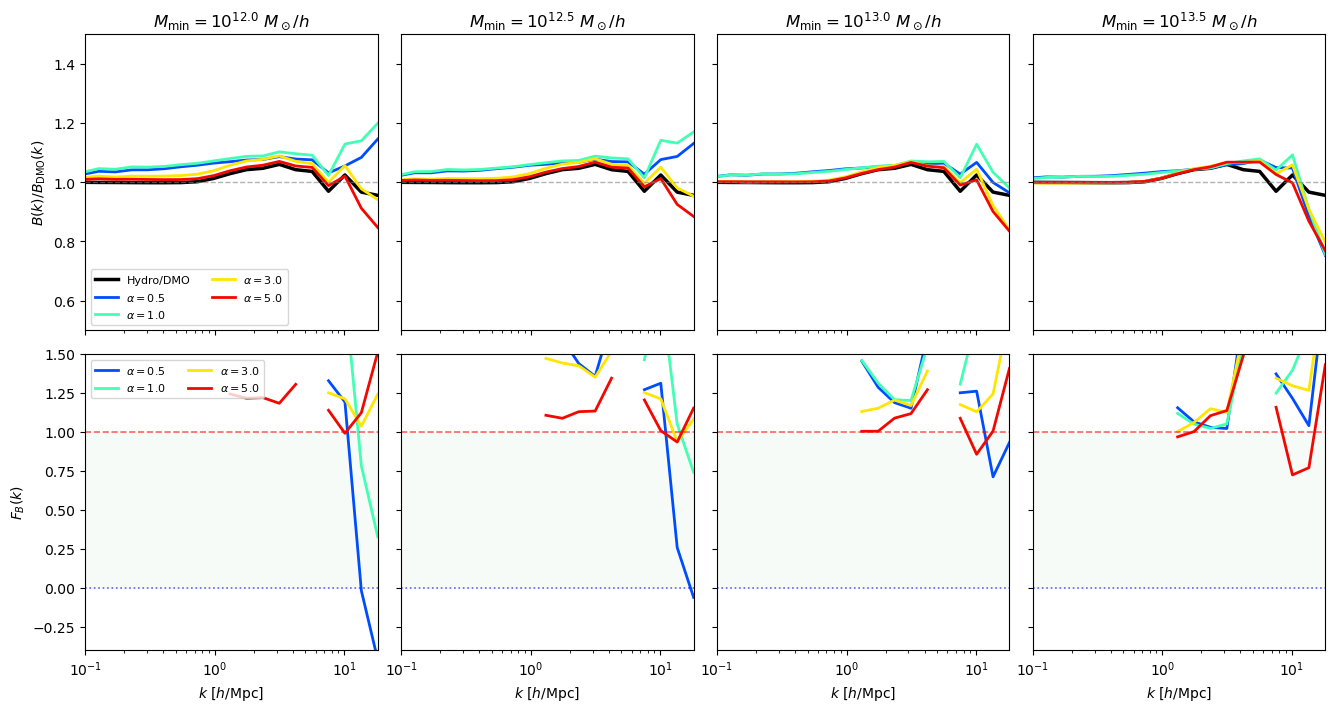

Figure 1: Scale-dependent bispectrum response saved.


In [43]:
# Figure 1: B(k) ratios + F_B(k) panels (scale-dependent bispectrum response)
# Row 0: 4 bispectrum ratio panels 
# Row 1: 4 scale-dependent F_B(k) panels

def compute_response_Fk_bispectrum(B_r, B_d, B_h, k, threshold=0.01):
    """Compute scale-dependent bispectrum response F_B(k)"""
    Delta_B = B_h - B_d
    significant = np.abs(Delta_B) > threshold * np.abs(B_d)
    F_k = np.zeros_like(B_r)
    F_k[significant] = (B_r[significant] - B_d[significant]) / Delta_B[significant]
    F_k[~significant] = np.nan
    return F_k

print(f"Using K_MIN = {K_MIN:.2f} h/Mpc (max across 20 LPs, where |B_H/B_D - 1| > {BARYONIC_THRESHOLD*100:.0f}%)")

fig = plt.figure(figsize=(16, 8))
gs = fig.add_gridspec(2, 4, height_ratios=[1, 1], hspace=0.08, wspace=0.08)

k = k_ref
B_d = bk_dmo_mean
B_h = bk_hydro_mean
Delta_B = B_h - B_d
significant = np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(B_d)

colors_alpha = plt.cm.jet(np.linspace(0.2, 0.9, len(RADII)))

# Row 0: Bispectrum ratios
ax_ratio = [fig.add_subplot(gs[0, j]) for j in range(4)]
for j in range(1, 4):
    ax_ratio[j].sharey(ax_ratio[0])
    ax_ratio[j].sharex(ax_ratio[0])

ratio_hydro = B_h / (B_d + 1e-30)
ratio_hydro_smooth = smooth_logk(ratio_hydro, window=3)

MASS_LABELS = [r'$10^{12}$', r'$10^{12.5}$', r'$10^{13}$', r'$10^{13.5}$']

for ax_idx, ml in enumerate(MASS_THRESHOLDS):
    ax = ax_ratio[ax_idx]
    ax.semilogx(k, ratio_hydro_smooth, lw=2.5, color='black', label='Hydro/DMO')
    
    for r_idx, r in enumerate(RADII):
        key = (ml, r)
        if key in cumulative_bk_all:
            B_r = cumulative_bk_all[key]['Bk_mean']
            ratio_r = B_r / (B_d + 1e-30)
            ratio_r_smooth = smooth_logk(ratio_r, window=3)
            ax.semilogx(k, ratio_r_smooth, lw=2, color=colors_alpha[r_idx], label=fr'$\alpha={r}$')
    
    ax.axhline(1.0, color='gray', ls='--', lw=1, alpha=0.6)
    mass_log = np.log10(float(ml))
    ax.set_title(fr'$M_{{\rm min}}=10^{{{mass_log:.1f}}}\ M_\odot/h$')
    ax.set_xlim(K_MIN, NYQUIST)
    ax.set_ylim(0.5, 1.5)
    if ax_idx == 0:
        ax.set_ylabel(r'$B(k)/B_{\rm DMO}(k)$')
        ax.legend(loc='lower left', fontsize=8, ncol=2)
    else:
        plt.setp(ax.get_yticklabels(), visible=False)

# Row 1: F_B(k)
ax_fk = [fig.add_subplot(gs[1, j], sharex=ax_ratio[j]) for j in range(4)]
for j in range(1, 4):
    ax_fk[j].sharey(ax_fk[0])

for ax in ax_ratio:
    plt.setp(ax.get_xticklabels(), visible=False)

for ax_idx, ml in enumerate(MASS_THRESHOLDS):
    ax = ax_fk[ax_idx]
    for r_idx, r in enumerate(RADII):
        key = (ml, r)
        if key in cumulative_bk_all:
            B_r = cumulative_bk_all[key]['Bk_mean']
            F_k = compute_response_Fk_bispectrum(B_r, B_d, B_h, k)
            F_k_smooth = smooth_logk(F_k, window=3)
            ax.semilogx(k, F_k_smooth, lw=2, color=colors_alpha[r_idx], label=fr'$\alpha={r}$')
    
    ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.6)
    ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.6)
    ax.axhspan(0, 1, alpha=0.03, color='green')
    ax.set_xlim(0.1, NYQUIST)
    ax.set_ylim(-0.4, 1.5)
    ax.set_xlabel(r'$k\ [h/\mathrm{Mpc}]$')
    if ax_idx == 0:
        ax.set_ylabel(r'$F_B(k)$')
        ax.legend(loc='upper left', fontsize=8, ncol=2)
    else:
        plt.setp(ax.get_yticklabels(), visible=False)

plt.tight_layout()
plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/fig1_bispectrum_scale_dependent_response.pdf')
plt.show()
print('Figure 1: Scale-dependent bispectrum response saved.')

---

## Figure 2: Cumulative Bispectrum Response Summary

Top row: Mean bispectrum response ⟨F_B⟩_k vs M_min (left, lines for each α) and vs α (right, lines for each M_min).

Bottom: Heatmap of cumulative ⟨F_B⟩ values for all (M_min, α) combinations.

Computing mean bispectrum response over k ∈ [4.21, 18.1] h/Mpc


/tmp/ipykernel_2285872/2317936327.py:99: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


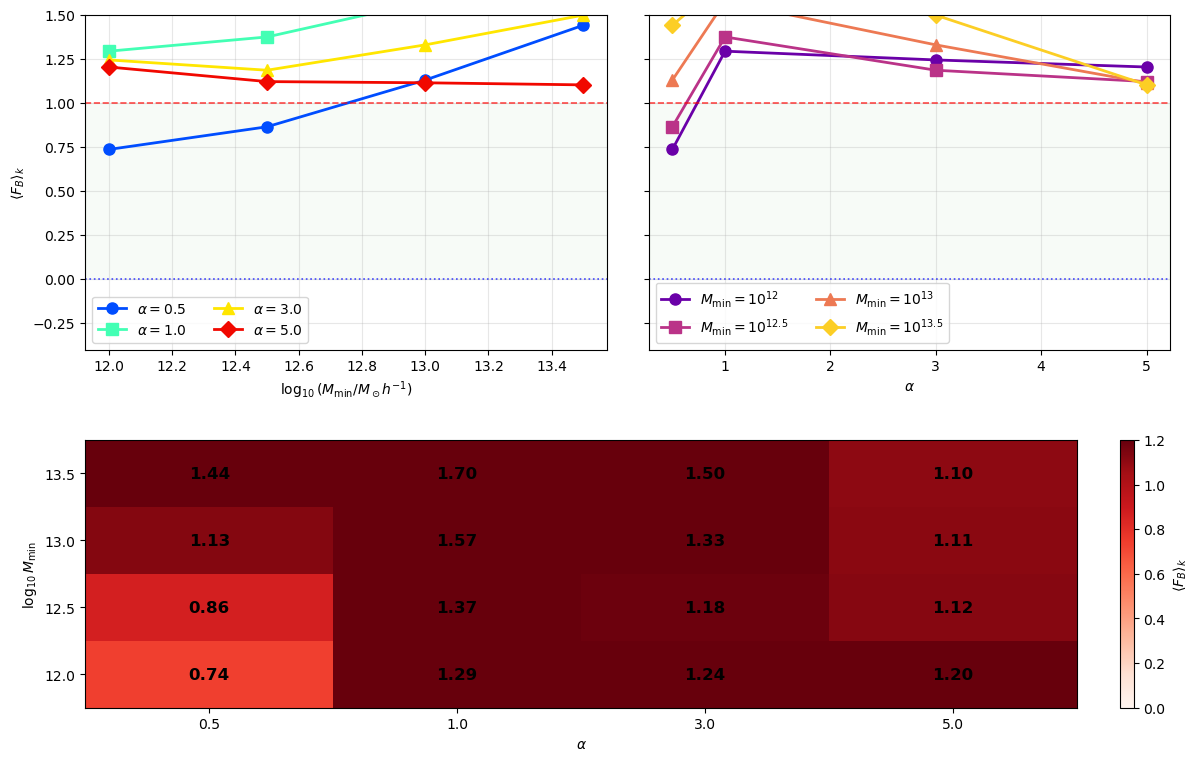

Figure 2: Cumulative bispectrum response summary saved.


In [44]:
# Figure 2: Cumulative bispectrum response panels + heatmap

def compute_mean_response_bispectrum(B_r, B_d, B_h, k, k_range=(1.0, 30.0)):
    """Compute mean bispectrum response F_B averaged over k range"""
    Delta_B = B_h - B_d
    in_range = (k >= k_range[0]) & (k <= min(k_range[1], NYQUIST))
    significant = np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(B_d)
    valid = in_range & significant
    if np.sum(valid) < 3:
        return np.nan
    return np.nanmean((B_r[valid] - B_d[valid]) / Delta_B[valid])

# Precompute heatmap matrix for bispectrum
n_mass = len(MASS_THRESHOLDS)
n_alpha = len(RADII)
F_Bk = np.full((n_mass, n_alpha), np.nan)
k_range = (K_MIN, NYQUIST)
print(f"Computing mean bispectrum response over k ∈ [{K_MIN:.2f}, {NYQUIST:.1f}] h/Mpc")

for i, ml in enumerate(MASS_THRESHOLDS):
    for j, r in enumerate(RADII):
        key = (ml, r)
        if key in cumulative_bk_all:
            F_Bk[i, j] = compute_mean_response_bispectrum(
                cumulative_bk_all[key]['Bk_mean'], bk_dmo_mean, bk_hydro_mean, k_ref, k_range=k_range
            )

fig = plt.figure(figsize=(14, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 0.8], hspace=0.3, wspace=0.08)

colors_alpha = plt.cm.jet(np.linspace(0.2, 0.9, len(RADII)))
colors_mass = plt.cm.plasma(np.linspace(0.2, 0.9, len(MASS_THRESHOLDS)))
markers = ['o', 's', '^', 'D']

LOG_MASS = [np.log10(float(m)) for m in MASS_THRESHOLDS]
ALPHA_VALUES = [float(r) for r in RADII]
MASS_LABELS = [r'$10^{12}$', r'$10^{12.5}$', r'$10^{13}$', r'$10^{13.5}$']

# Row 0: Cumulative response (2 panels)
ax0 = fig.add_subplot(gs[0, 0])
ax1 = fig.add_subplot(gs[0, 1], sharey=ax0)

# Left: fixed α, varying M_min
for r_idx, r in enumerate(RADII):
    means = []
    for ml in MASS_THRESHOLDS:
        key = (ml, r)
        if key in cumulative_bk_all:
            means.append(compute_mean_response_bispectrum(
                cumulative_bk_all[key]['Bk_mean'], bk_dmo_mean, bk_hydro_mean, k_ref, k_range=k_range))
        else:
            means.append(np.nan)
    ax0.plot(LOG_MASS, means, marker=markers[r_idx], color=colors_alpha[r_idx], lw=2, ms=8, label=fr'$\alpha={r}$')
ax0.set_xlabel(r'$\log_{10}(M_{\rm min}/M_\odot h^{-1})$')
ax0.set_ylabel(r'$\langle F_B \rangle_k$')

# Right: fixed M_min, varying α
for m_idx, ml in enumerate(MASS_THRESHOLDS):
    means = []
    for r in RADII:
        key = (ml, r)
        if key in cumulative_bk_all:
            means.append(compute_mean_response_bispectrum(
                cumulative_bk_all[key]['Bk_mean'], bk_dmo_mean, bk_hydro_mean, k_ref, k_range=k_range))
        else:
            means.append(np.nan)
    ax1.plot(ALPHA_VALUES, means, marker=markers[m_idx], color=colors_mass[m_idx], lw=2, ms=8, 
             label=r'$M_{\rm min}=$' + MASS_LABELS[m_idx])
ax1.set_xlabel(r'$\alpha$')
plt.setp(ax1.get_yticklabels(), visible=False)

for ax in (ax0, ax1):
    ax.axhline(1.0, color='red', ls='--', lw=1.2, alpha=0.7)
    ax.axhline(0.0, color='blue', ls=':', lw=1.2, alpha=0.7)
    ax.set_ylim(-0.4, 1.5)
    ax.grid(True, alpha=0.3)
    ax.axhspan(0, 1, alpha=0.03, color='green')
ax0.legend(loc='best', ncol=2)
ax1.legend(loc='best', ncol=2)

# Row 1: Heatmap
ax2 = fig.add_subplot(gs[1, :])
im = ax2.imshow(F_Bk, cmap='Reds', vmin=0, vmax=1.2, aspect='auto', origin='lower')
ax2.set_xticks(range(n_alpha))
ax2.set_xticklabels(RADII)
ax2.set_yticks(range(n_mass))
ax2.set_yticklabels([f'{np.log10(float(m)):.1f}' for m in MASS_THRESHOLDS])
ax2.set_xlabel(r'$\alpha$')
ax2.set_ylabel(r'$\log_{10}M_{\rm min}$')
ax2.grid(False)
for i in range(n_mass):
    for j in range(n_alpha):
        val = F_Bk[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=12, fontweight='bold')
cbar = plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)
cbar.set_label(r'$\langle F_B \rangle_k$')

plt.tight_layout()
plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/fig2_bispectrum_cumulative_response_summary.pdf')
plt.show()
print('Figure 2: Cumulative bispectrum response summary saved.')

---

## Figure 3: Tile Bispectrum Response Heatmap with Marginal Subplots

Shows the average tile bispectrum response ⟨ΔF_B⟩ matrix with marginal line plots for mass and radius dependencies.

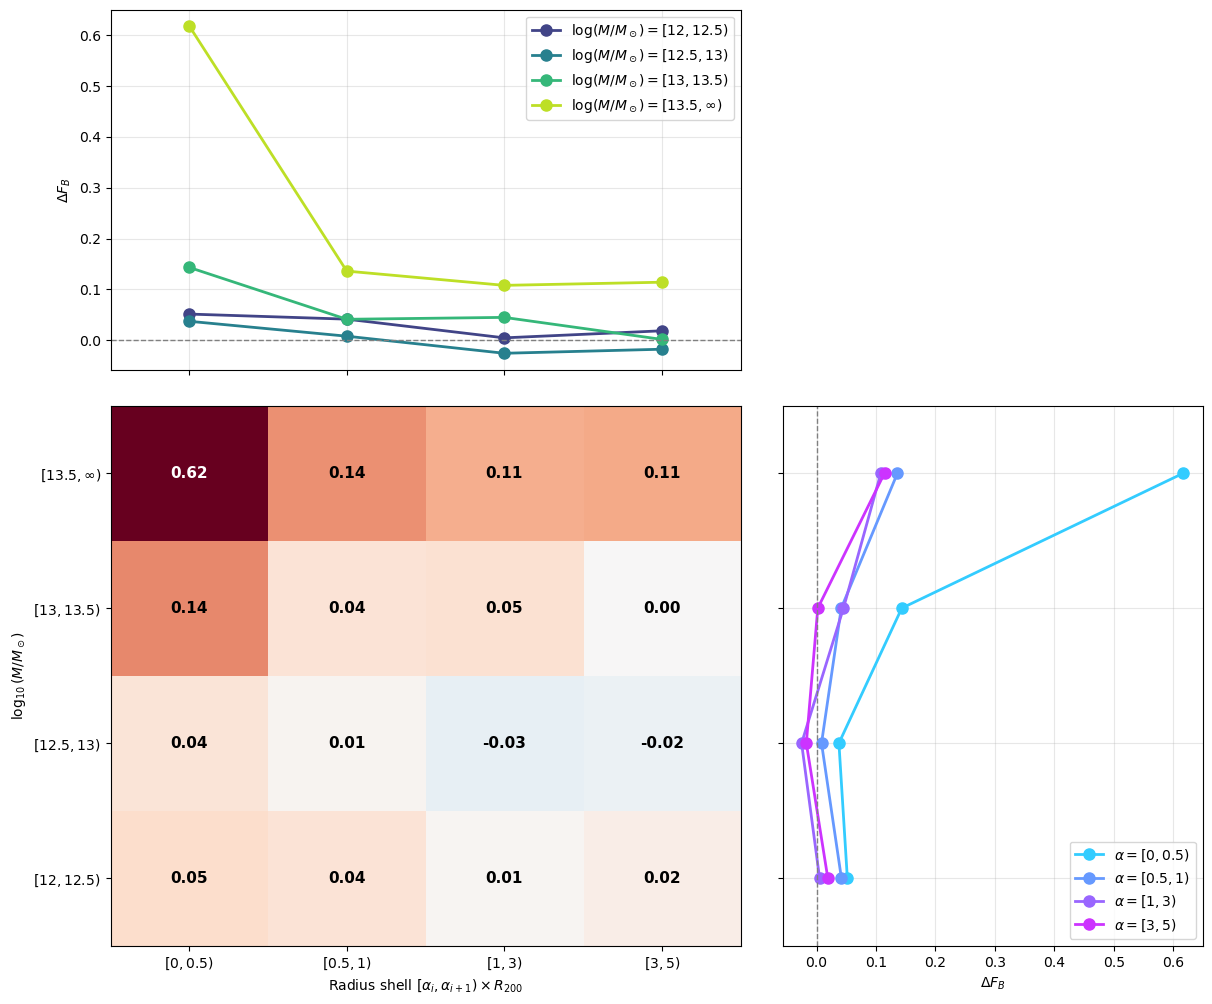

In [41]:
# Figure 3: Multi-LP Tile Bispectrum Response Heatmap with marginal subplots
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Create figure with marginal subplots
fig = plt.figure(figsize=(14, 12))

# Main heatmap axes (center)
ax_main = fig.add_axes([0.12, 0.12, 0.45, 0.45])

# Top marginal
ax_top = fig.add_axes([0.12, 0.60, 0.45, 0.30], sharex=ax_main)

# Right marginal
ax_right = fig.add_axes([0.60, 0.12, 0.30, 0.45], sharey=ax_main)

# Clean labels
MASS_LABELS_LOG = [r'$[12, 12.5)$', r'$[12.5, 13)$', 
                   r'$[13, 13.5)$', r'$[13.5, \infty)$']
RADIUS_LABELS_CLEAN = [r'$[0, 0.5)$', r'$[0.5, 1)$', r'$[1, 3)$', r'$[3, 5)$']

# Main heatmap
im = ax_main.imshow(Delta_F_matrix_multiLP, cmap='RdBu_r', aspect='auto', 
                    vmin=-0.3, vmax=0.3, origin='lower')
ax_main.set_xticks(range(n_radius_disc))
ax_main.set_xticklabels(RADIUS_LABELS_CLEAN)
ax_main.set_yticks(range(n_mass_disc))
ax_main.set_yticklabels(MASS_LABELS_LOG)
ax_main.set_xlabel(r'Radius shell $[\alpha_i, \alpha_{i+1}) \times R_{200}$')
ax_main.set_ylabel(r'$\log_{10}(M/M_\odot)$')

# Annotate with values
for i in range(n_mass_disc):
    for j in range(n_radius_disc):
        val = Delta_F_matrix_multiLP[i, j]
        if not np.isnan(val):
            color = 'white' if abs(val) > 0.15 else 'black'
            ax_main.text(j, i, f'{val:.2f}', ha='center', va='center', 
                        fontsize=11, color=color, fontweight='bold')

# Top marginal: radius response for each mass bin
colors_mass = plt.cm.viridis(np.linspace(0.2, 0.9, n_mass_disc))
x_radius = np.arange(n_radius_disc)
for i, (ml, mu) in enumerate(DISCRETE_MASS_BINS):
    ax_top.plot(x_radius, Delta_F_matrix_multiLP[i, :], 'o-', 
                color=colors_mass[i], lw=2, markersize=8,
                label=r'$\log(M/M_\odot)=$' + MASS_LABELS_LOG[i])
ax_top.axhline(0, color='gray', ls='--', lw=1)
ax_top.set_ylabel(r'$\Delta F_B$')
ax_top.legend(loc='upper right', ncol=1)
ax_top.grid(True, alpha=0.3)
plt.setp(ax_top.get_xticklabels(), visible=False)
ax_top.set_xlim(-0.5, n_radius_disc - 0.5)

# Right marginal: mass response for each radius shell
colors_radius = plt.cm.cool(np.linspace(0.2, 0.8, n_radius_disc))
y_mass = np.arange(n_mass_disc)
for j, (ri, ro) in enumerate(DISCRETE_RADIUS_BINS):
    ax_right.plot(Delta_F_matrix_multiLP[:, j], y_mass, 'o-', 
                  color=colors_radius[j], lw=2, markersize=8,
                  label=r'$\alpha=$' + RADIUS_LABELS_CLEAN[j])
ax_right.axvline(0, color='gray', ls='--', lw=1)
ax_right.set_xlabel(r'$\Delta F_B$')
ax_right.legend(loc='lower right')
ax_right.grid(True, alpha=0.3)
plt.setp(ax_right.get_yticklabels(), visible=False)
ax_right.set_ylim(-0.5, n_mass_disc - 0.5)

plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/fig3_bispectrum_tile_response_heatmap_multiLP.pdf')
plt.show()

---

## Figure 4: Scale-dependent Tile Bispectrum Response ΔF_B(k)

Shows the tile bispectrum response as a function of wavenumber k, with 4 panels (one per mass bin) and 4 lines (one per radial bin).

/tmp/ipykernel_2285872/4144753265.py:28: RuntimeWarning: Mean of empty slice
  Delta_F_k_mean = np.nanmean(Delta_F_k_all, axis=0)
/mnt/home/mlee1/venvs/hydro_replace/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


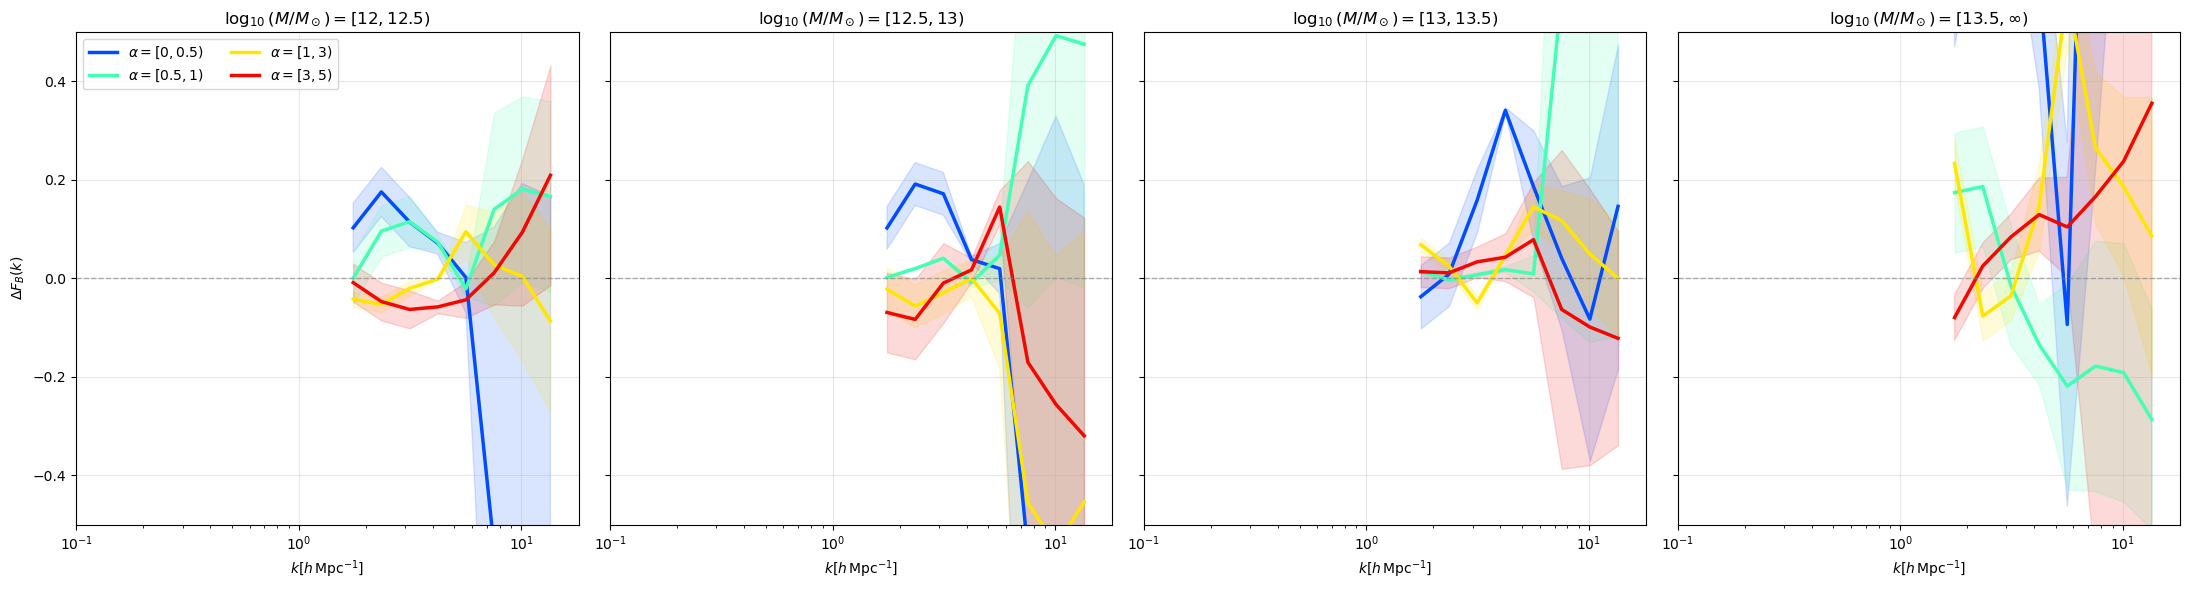

In [30]:
# Figure 4: Tile bispectrum response ΔF_B(k) as a function of k with error bands
# 4 panels (one per mass bin), each with 4 lines (one per radial bin)

fig, axes = plt.subplots(1, 4, figsize=(22, 6), sharex=True, sharey=True)

# Colors for radius bins
colors_radius = plt.cm.jet(np.linspace(0.2, 0.9, len(DISCRETE_RADIUS_BINS)))

# ΔF_B(k) for each tile with error bands from LP-to-LP variance
for i, (ml, mu) in enumerate(DISCRETE_MASS_BINS):
    ax = axes[i]
    
    for j, (ri, ro) in enumerate(DISCRETE_RADIUS_BINS):
        key = (ml, mu, ri, ro)
        if key in discrete_bk_all:
            # Get B(k) for all lensplanes
            bk_tile_all = discrete_bk_all[key]['Bk_all']
            n_lp = bk_tile_all.shape[0]
            
            # Compute ΔF_B(k) for EACH lensplane
            Delta_F_k_all = np.full((n_lp, len(k_all)), np.nan)
            for lp in range(n_lp):
                Delta_B = hydro_bks_all[lp] - dmo_bks_all[lp]
                significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(dmo_bks_all[lp])) & (k_all < NYQUIST)
                Delta_F_k_all[lp, significant] = (bk_tile_all[lp, significant] - dmo_bks_all[lp, significant]) / Delta_B[significant]
            
            # Mean and std across lensplanes
            Delta_F_k_mean = np.nanmean(Delta_F_k_all, axis=0)
            Delta_F_k_std = np.nanstd(Delta_F_k_all, axis=0)
            
            # Smooth for visualization
            Delta_F_k_smooth = smooth_logk(Delta_F_k_mean, window=3)
            Delta_F_k_std_smooth = smooth_logk(Delta_F_k_std, window=3)
            
            # Plot with error band (1-sigma standard deviation)
            ax.fill_between(k_all, Delta_F_k_smooth - Delta_F_k_std_smooth, 
                           Delta_F_k_smooth + Delta_F_k_std_smooth,
                           color=colors_radius[j], alpha=0.15)
            ax.semilogx(k_all, Delta_F_k_smooth, lw=2.5, color=colors_radius[j],
                       label=r'$\alpha=$' + RADIUS_LABELS_CLEAN[j])
    
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
    ax.set_xlim(0.1, NYQUIST)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(r'$\log_{10}(M/M_\odot)=$' + MASS_LABELS_LOG[i])
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r'$k [h\,{\rm Mpc}^{-1}]$')
    
    if i == 0:
        ax.legend(loc='upper left', ncols=2)
        ax.set_ylabel(r'$\Delta F_{B}(k)$')

plt.tight_layout()
plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/fig4_bispectrum_tile_response_Fk_by_mass.pdf')
plt.show()

---

## Figure 5: Bispectrum Non-additivity ε(k)

Shows the non-additivity parameter ε(k) = (F_B,cum - Σ ΔF_B) comparing cumulative bispectrum models vs sum of discrete tiles.

- **Top row**: Organized by mass threshold, with radius as colors
- **Bottom row**: Organized by radius threshold, with mass as colors

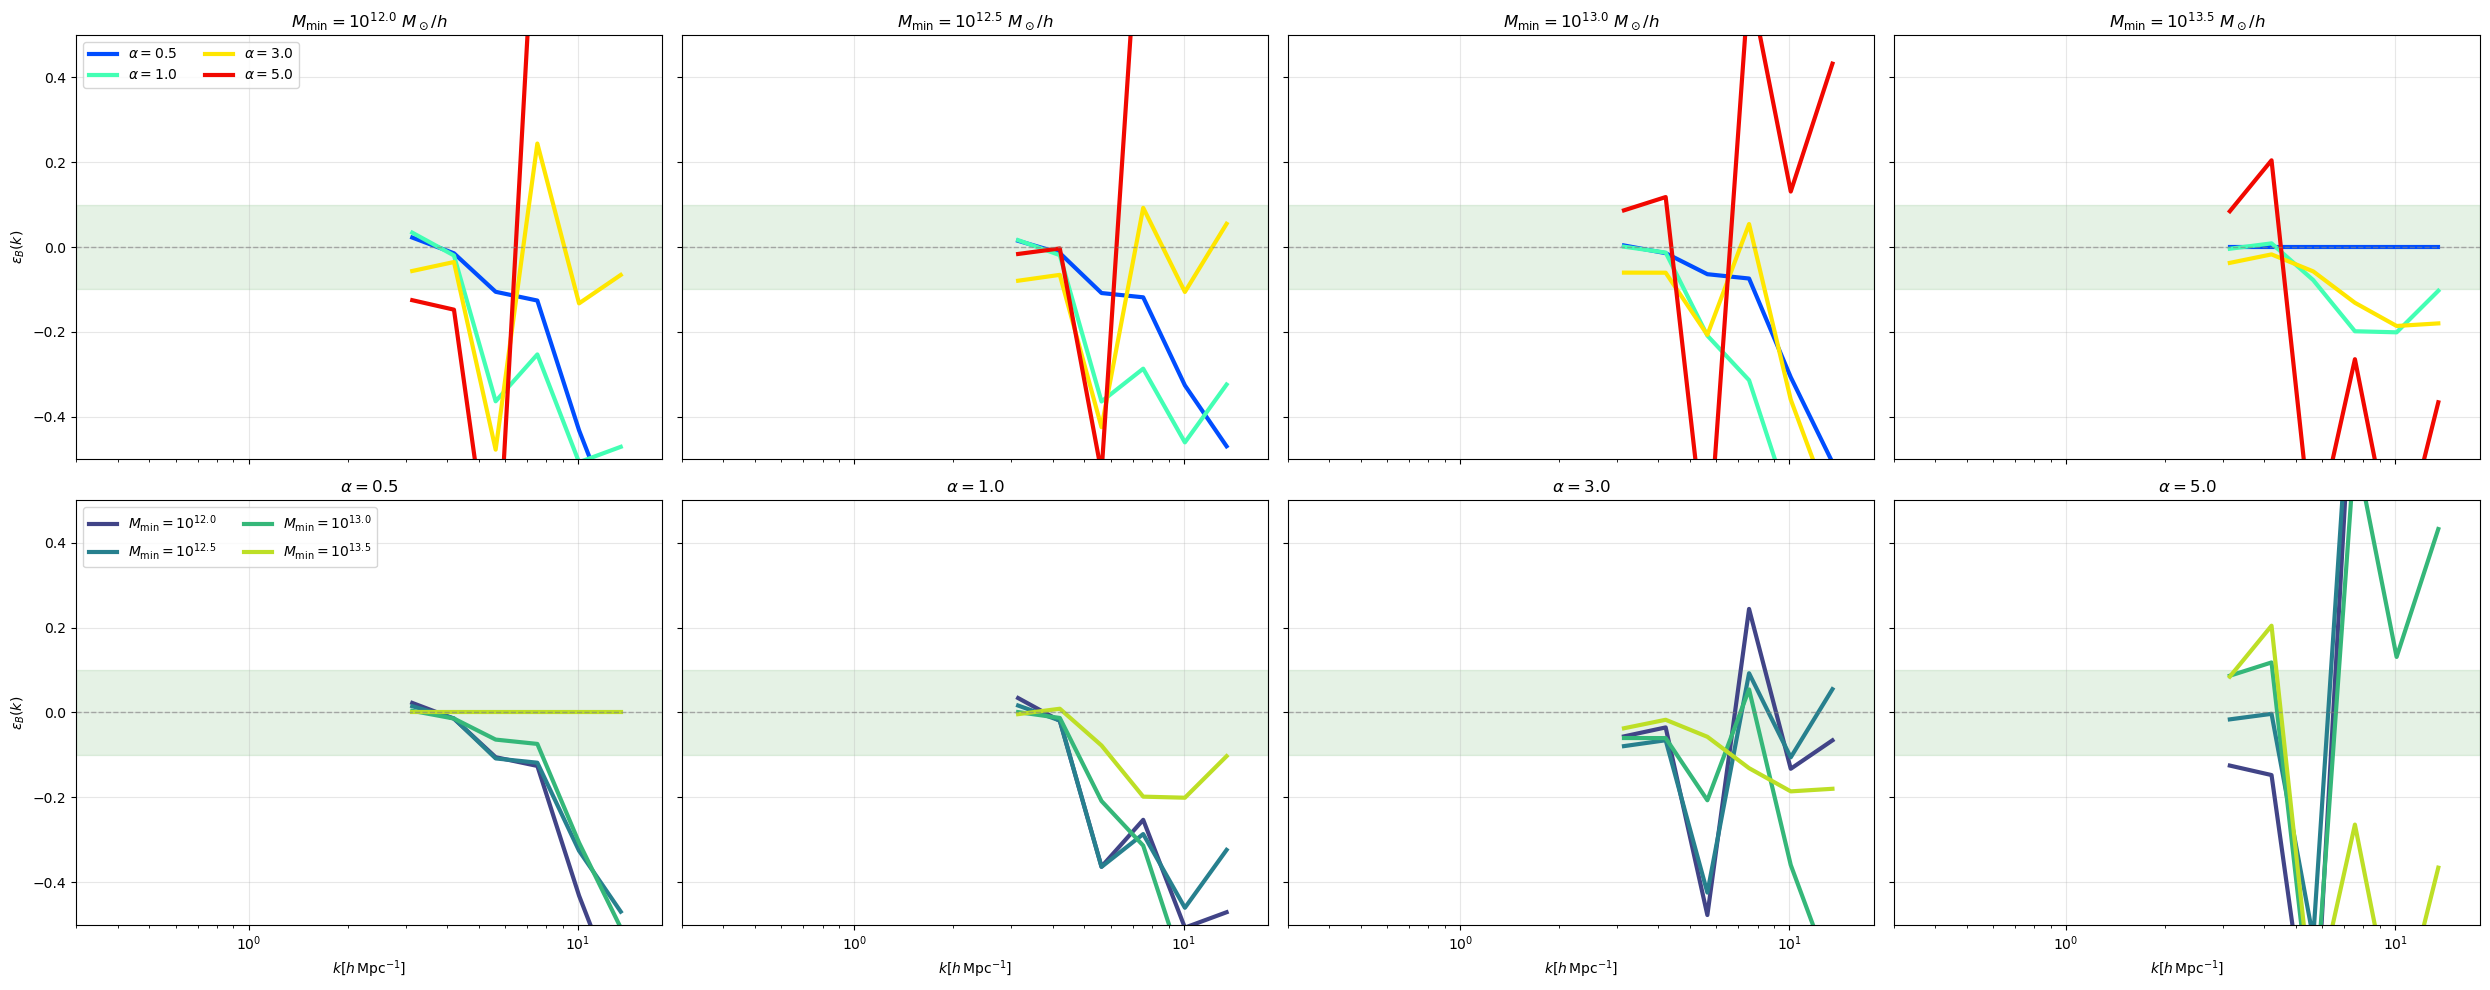


Mean bispectrum non-additivity ε_B across k:
------------------------------------------------------------
  M_min=1.00e12, α=0.5: ⟨ε_B⟩ = -0.187
  M_min=1.00e12, α=1.0: ⟨ε_B⟩ = -0.217
  M_min=1.00e12, α=3.0: ⟨ε_B⟩ = -0.079
  M_min=1.00e12, α=5.0: ⟨ε_B⟩ = +0.333
  M_min=3.16e12, α=0.5: ⟨ε_B⟩ = -0.143
  M_min=3.16e12, α=1.0: ⟨ε_B⟩ = -0.200
  M_min=3.16e12, α=3.0: ⟨ε_B⟩ = -0.086
  M_min=3.16e12, α=5.0: ⟨ε_B⟩ = +0.423
  M_min=1.00e13, α=0.5: ⟨ε_B⟩ = -0.137
  M_min=1.00e13, α=1.0: ⟨ε_B⟩ = -0.268
  M_min=1.00e13, α=3.0: ⟨ε_B⟩ = -0.186
  M_min=1.00e13, α=5.0: ⟨ε_B⟩ = +0.098
  M_min=3.16e13, α=0.5: ⟨ε_B⟩ = +0.000
  M_min=3.16e13, α=1.0: ⟨ε_B⟩ = -0.083
  M_min=3.16e13, α=3.0: ⟨ε_B⟩ = -0.092
  M_min=3.16e13, α=5.0: ⟨ε_B⟩ = -0.257


In [31]:
# Figure 5: Bispectrum Non-additivity ε(k) = (F_B,cum - Σ ΔF_B)
# Top row: 4 panels by mass threshold, each with 4 radius lines
# Bottom row: 4 panels by radius threshold, each with 4 mass lines

fig, axes = plt.subplots(2, 4, figsize=(25, 10), sharex=True, sharey=True)

# Colors for radius and mass thresholds
colors_radius = plt.cm.jet(np.linspace(0.2, 0.9, len(RADII)))
colors_mass = plt.cm.viridis(np.linspace(0.2, 0.9, len(MASS_THRESHOLDS)))

# === Top row: Organized by mass threshold, radius as colors ===
for m_idx, ml in enumerate(MASS_THRESHOLDS):
    ax = axes[0, m_idx]
    mass_start = MASS_TO_BIN_START[ml]
    
    for a_idx, alpha in enumerate(RADII):
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        
        radius_end = RADIUS_TO_BIN_END[alpha]
        
        # Compute F_B,cum(k) from cumulative model
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_all < NYQUIST)
        
        F_cum_k = np.full_like(Bk_cum, np.nan)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        # Sum tiles: mass bins from mass_start to end, radius bins from 0 to radius_end
        F_sum_k = np.zeros_like(k_all)
        for ii in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_tile, mu_tile = DISCRETE_MASS_BINS[ii]
            for jj in range(radius_end):
                ri_tile, ro_tile = DISCRETE_RADIUS_BINS[jj]
                tile_key = (ml_tile, mu_tile, ri_tile, ro_tile)
                if tile_key in discrete_bk_all:
                    Bk_tile = discrete_bk_all[tile_key]['Bk_mean']
                    Delta_F_tile = np.zeros_like(Bk_tile)
                    Delta_F_tile[significant] = (Bk_tile[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                    F_sum_k += Delta_F_tile
        
        # Compute ε(k) = F_cum - F_sum (absolute difference)
        epsilon_k = np.full_like(F_cum_k, np.nan)
        valid = significant & (np.abs(F_cum_k) > 0.01)
        epsilon_k[valid] = (F_cum_k[valid] - F_sum_k[valid])
        
        # Smooth for visualization
        epsilon_k_smooth = smooth_logk(epsilon_k, window=3)
        
        ax.semilogx(k_all, epsilon_k_smooth, lw=3, color=colors_radius[a_idx],
                   label=r'$\alpha=' + alpha + r'$')
    
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
    ax.axhspan(-0.1, 0.1, alpha=0.1, color='green')
    ax.set_xlim(0.3, NYQUIST)
    ax.set_ylim(-0.5, 0.5)
    mass_log = np.log10(float(ml))
    ax.set_title(rf'$M_{{\rm min}} = 10^{{{mass_log:.1f}}}\ M_\odot/h$')
    ax.grid(True, alpha=0.3)
    
    if m_idx == 0:
        ax.legend(loc='upper left', ncols=2)
        ax.set_ylabel(r'$\varepsilon_B(k)$')

# === Bottom row: Organized by radius threshold, mass as colors ===
for a_idx, alpha in enumerate(RADII):
    ax = axes[1, a_idx]
    radius_end = RADIUS_TO_BIN_END[alpha]
    
    for m_idx, ml in enumerate(MASS_THRESHOLDS):
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        
        mass_start = MASS_TO_BIN_START[ml]
        
        # Compute F_B,cum(k) from cumulative model
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_all < NYQUIST)
        
        F_cum_k = np.full_like(Bk_cum, np.nan)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        # Sum tiles
        F_sum_k = np.zeros_like(k_all)
        for ii in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_tile, mu_tile = DISCRETE_MASS_BINS[ii]
            for jj in range(radius_end):
                ri_tile, ro_tile = DISCRETE_RADIUS_BINS[jj]
                tile_key = (ml_tile, mu_tile, ri_tile, ro_tile)
                if tile_key in discrete_bk_all:
                    Bk_tile = discrete_bk_all[tile_key]['Bk_mean']
                    Delta_F_tile = np.zeros_like(Bk_tile)
                    Delta_F_tile[significant] = (Bk_tile[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                    F_sum_k += Delta_F_tile
        
        # Compute ε(k)
        epsilon_k = np.full_like(F_cum_k, np.nan)
        valid = significant & (np.abs(F_cum_k) > 0.01)
        epsilon_k[valid] = (F_cum_k[valid] - F_sum_k[valid])
        
        # Smooth for visualization
        epsilon_k_smooth = smooth_logk(epsilon_k, window=3)
        
        mass_log = np.log10(float(ml))
        ax.semilogx(k_all, epsilon_k_smooth, lw=3, color=colors_mass[m_idx],
                   label=rf'$M_{{\rm min}}=10^{{{mass_log:.1f}}}$')
    
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
    ax.axhspan(-0.1, 0.1, alpha=0.1, color='green')
    ax.set_xlim(0.3, NYQUIST)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r'$k [h\,{\rm Mpc}^{-1}]$')
    
    if a_idx == 0:
        ax.legend(loc='upper left', ncols=2)
        ax.set_ylabel(r'$\varepsilon_B(k)$')

plt.tight_layout()
plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/fig5_bispectrum_epsilon_k_additivity.pdf')
plt.show()

# Print mean epsilon for each configuration
print("\nMean bispectrum non-additivity ε_B across k:")
print("-" * 60)
for ml in MASS_THRESHOLDS:
    mass_start = MASS_TO_BIN_START[ml]
    for alpha in RADII:
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        radius_end = RADIUS_TO_BIN_END[alpha]
        
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_all < NYQUIST)
        
        F_cum_k = np.zeros_like(Bk_cum)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        F_sum_k = np.zeros_like(k_all)
        for ii in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_tile, mu_tile = DISCRETE_MASS_BINS[ii]
            for jj in range(radius_end):
                ri_tile, ro_tile = DISCRETE_RADIUS_BINS[jj]
                tile_key = (ml_tile, mu_tile, ri_tile, ro_tile)
                if tile_key in discrete_bk_all:
                    Bk_tile = discrete_bk_all[tile_key]['Bk_mean']
                    Delta_F_tile = np.zeros_like(Bk_tile)
                    Delta_F_tile[significant] = (Bk_tile[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                    F_sum_k += Delta_F_tile
        
        valid = significant & (np.abs(F_cum_k) > 0.01)
        epsilon_k = (F_cum_k[valid] - F_sum_k[valid])
        print(f"  M_min={ml}, α={alpha}: ⟨ε_B⟩ = {np.nanmean(epsilon_k):+.3f}")

---

## Understanding Bispectrum Non-Additivity: Mass vs Radius Contributions

We have 100 models total:
- **16 Cumulative × Cumulative**: M > M_min, R < α (the full cumulative models)
- **16 Exclusive × Exclusive**: M ∈ [M_a, M_b), R ∈ [α_i, α_j) (the discrete tiles)
- **16 Exclusive Mass × Cumulative Radius**: M ∈ [M_a, M_b), R < α
- **52 Cumulative Mass × Exclusive Radius**: M > M_min, R ∈ [α_i, α_j)

The **exclusive mass × cumulative radius** models let us test **MASS additivity at fixed radius**:
$$F_B(M > M_{\min}, R < \alpha) \stackrel{?}{=} \sum_i F_B([M_i, M_{i+1}), R < \alpha)$$

If this holds, non-additivity comes from **radial cross-terms** (same halo, different shells).
If this fails, non-additivity comes from **mass cross-terms** (different halos interfering).

**Bispectrum-specific note**: The bispectrum involves three-point correlations, so we expect potentially different non-additivity behavior compared to the power spectrum.

In [32]:
# Scan and categorize all models
import re

def parse_model_name_full(dirname):
    """Parse model directory name to extract mass and radius configuration"""
    # Pattern for cumulative mass, cumulative radius: Ml_X_Mu_inf_R_Y  
    # (Note: these use Mu_1.00e15 as "inf" and Ri_0.0 implicitly)
    if '_Ri_0.0_Ro_' in dirname and '_Mu_1.00e15_' in dirname:
        match = re.search(r'Ml_([0-9.e]+)_Mu_1.00e15_Ri_0.0_Ro_([0-9.]+)', dirname)
        if match:
            return {
                'mass_type': 'cumulative',
                'mass_lo': match.group(1),
                'mass_hi': '1.00e15',
                'radius_type': 'cumulative',
                'radius_lo': '0.0',
                'radius_hi': match.group(2)
            }
    
    # Pattern for exclusive mass, cumulative radius: Ml_X_Mu_Y_Ri_0.0_Ro_Z (where Y != 1.00e15)
    if '_Ri_0.0_Ro_' in dirname and '_Mu_1.00e15_' not in dirname:
        match = re.search(r'Ml_([0-9.e]+)_Mu_([0-9.e]+)_Ri_0.0_Ro_([0-9.]+)', dirname)
        if match:
            return {
                'mass_type': 'exclusive',
                'mass_lo': match.group(1),
                'mass_hi': match.group(2),
                'radius_type': 'cumulative',
                'radius_lo': '0.0',
                'radius_hi': match.group(3)
            }
    
    # Pattern for cumulative mass, exclusive radius: Ml_X_Mu_1.00e15_Ri_A_Ro_B (where A != 0)
    if '_Mu_1.00e15_Ri_' in dirname:
        match = re.search(r'Ml_([0-9.e]+)_Mu_1.00e15_Ri_([0-9.]+)_Ro_([0-9.]+)', dirname)
        if match and match.group(2) != '0.0':
            return {
                'mass_type': 'cumulative',
                'mass_lo': match.group(1),
                'mass_hi': '1.00e15',
                'radius_type': 'exclusive',
                'radius_lo': match.group(2),
                'radius_hi': match.group(3)
            }
    
    # Pattern for exclusive mass, exclusive radius: Ml_X_Mu_Y_Ri_A_Ro_B
    match = re.search(r'Ml_([0-9.e]+)_Mu_([0-9.e]+)_Ri_([0-9.]+)_Ro_([0-9.]+)', dirname)
    if match and match.group(2) != '1.00e15':
        return {
            'mass_type': 'exclusive',
            'mass_lo': match.group(1),
            'mass_hi': match.group(2),
            'radius_type': 'exclusive',
            'radius_lo': match.group(3),
            'radius_hi': match.group(4)
        }
    
    return None

# Scan all models
all_models = {}
for dirname in os.listdir(replace_path):
    if dirname.startswith('hydro_replace_'):
        config = parse_model_name_full(dirname)
        if config:
            all_models[dirname] = config

# Categorize
cum_mass_cum_radius = []  # Cumulative × Cumulative
exc_mass_exc_radius = []  # Exclusive × Exclusive (tiles)
cum_mass_exc_radius = []  # Mixed: radial additivity test
exc_mass_cum_radius = []  # Mixed: mass additivity test

for name, cfg in all_models.items():
    key = (cfg['mass_type'], cfg['radius_type'])
    if key == ('cumulative', 'cumulative'):
        cum_mass_cum_radius.append((name, cfg))
    elif key == ('exclusive', 'exclusive'):
        exc_mass_exc_radius.append((name, cfg))
    elif key == ('cumulative', 'exclusive'):
        cum_mass_exc_radius.append((name, cfg))
    elif key == ('exclusive', 'cumulative'):
        exc_mass_cum_radius.append((name, cfg))

print(f"Model categorization:")
print(f"  Cumulative mass × Cumulative radius: {len(cum_mass_cum_radius)}")
print(f"  Exclusive mass × Exclusive radius:   {len(exc_mass_exc_radius)}")
print(f"  Cumulative mass × Exclusive radius:  {len(cum_mass_exc_radius)}")
print(f"  Exclusive mass × Cumulative radius:  {len(exc_mass_cum_radius)}")
print(f"  Total categorized: {len(all_models)}")

Model categorization:
  Cumulative mass × Cumulative radius: 16
  Exclusive mass × Exclusive radius:   36
  Cumulative mass × Exclusive radius:  24
  Exclusive mass × Cumulative radius:  24
  Total categorized: 100


In [13]:
# Print the exclusive mass × cumulative radius models (for mass additivity test)
print("Exclusive Mass × Cumulative Radius Models:")
print("=" * 70)
print(f"{'Mass Range':<30} {'Radius':<15} {'Model Name'}")
print("-" * 70)
for name, cfg in sorted(exc_mass_cum_radius, key=lambda x: (x[1]['mass_lo'], x[1]['radius_hi'])):
    mass_range = f"[{cfg['mass_lo']}, {cfg['mass_hi']})"
    radius = f"R < {cfg['radius_hi']}"
    print(f"{mass_range:<30} {radius:<15} {name}")

print(f"\nTotal: {len(exc_mass_cum_radius)} models")
print("\nThese allow testing: F(M > M_min, R < α) = Σ F([M_i, M_{i+1}), R < α) ?")

Exclusive Mass × Cumulative Radius Models:
Mass Range                     Radius          Model Name
----------------------------------------------------------------------
[1.00e12, 1.00e13)             R < 0.5         hydro_replace_Ml_1.00e12_Mu_1.00e13_Ri_0.0_Ro_0.5
[1.00e12, 3.16e13)             R < 0.5         hydro_replace_Ml_1.00e12_Mu_3.16e13_Ri_0.0_Ro_0.5
[1.00e12, 3.16e12)             R < 0.5         hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_0.0_Ro_0.5
[1.00e12, 1.00e13)             R < 1.0         hydro_replace_Ml_1.00e12_Mu_1.00e13_Ri_0.0_Ro_1.0
[1.00e12, 3.16e13)             R < 1.0         hydro_replace_Ml_1.00e12_Mu_3.16e13_Ri_0.0_Ro_1.0
[1.00e12, 3.16e12)             R < 1.0         hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_0.0_Ro_1.0
[1.00e12, 1.00e13)             R < 3.0         hydro_replace_Ml_1.00e12_Mu_1.00e13_Ri_0.0_Ro_3.0
[1.00e12, 3.16e12)             R < 3.0         hydro_replace_Ml_1.00e12_Mu_3.16e12_Ri_0.0_Ro_3.0
[1.00e12, 3.16e13)             R < 3.0         hydro

In [ ]:
# Load exclusive mass × cumulative radius models for all 20 lensplanes
print("Loading exclusive mass × cumulative radius models...")

def load_exc_mass_cum_radius_bk_all_lps(Ml_str, Mu_str, Ro_str):
    """Load B(k) for an exclusive mass, cumulative radius model across all lensplanes"""
    model_dir = f"{replace_path}/hydro_replace_Ml_{Ml_str}_Mu_{Mu_str}_Ri_0.0_Ro_{Ro_str}"
    bks = []
    for lp_idx in range(N_LENSPLANES):
        filepath = f"{model_dir}/LP_{lp_idx:02d}/lenspot00.dat"
        if os.path.exists(filepath):
            plane = read_lensplane(filepath)
            k, bk = compute_equilateral_bispectrum(plane, BOX_SIZE, kmax=K_MAX_BK)
            bks.append(bk)
    return np.array(bks) if len(bks) == N_LENSPLANES else None

# Load all exclusive mass × cumulative radius models
exc_mass_cum_radius_bk_all = {}

for name, cfg in exc_mass_cum_radius:
    ml, mu, ro = cfg['mass_lo'], cfg['mass_hi'], cfg['radius_hi']
    bks = load_exc_mass_cum_radius_bk_all_lps(ml, mu, ro)
    if bks is not None:
        exc_mass_cum_radius_bk_all[(ml, mu, ro)] = {
            'Bk_all': bks,
            'Bk_mean': np.mean(bks, axis=0),
            'Bk_std': np.std(bks, axis=0)
        }
        print(f"  M=[{ml},{mu}), R<{ro}: {len(bks)} lensplanes")

print(f"\nLoaded {len(exc_mass_cum_radius_bk_all)} exclusive mass × cumulative radius models")

Loading exclusive mass × cumulative radius models...


  M=[1.00e12,1.00e13), R<1.0: 20 lensplanes
  M=[3.16e12,3.16e13), R<5.0: 20 lensplanes
  M=[3.16e12,1.00e13), R<5.0: 20 lensplanes
  M=[1.00e13,3.16e13), R<0.5: 20 lensplanes
  M=[1.00e12,3.16e13), R<1.0: 20 lensplanes
  M=[1.00e12,3.16e12), R<5.0: 20 lensplanes
  M=[3.16e12,3.16e13), R<1.0: 20 lensplanes
  M=[1.00e12,1.00e13), R<3.0: 20 lensplanes
  M=[1.00e12,3.16e12), R<3.0: 20 lensplanes
  M=[3.16e12,1.00e13), R<1.0: 20 lensplanes
  M=[1.00e12,1.00e13), R<0.5: 20 lensplanes
  M=[3.16e12,3.16e13), R<0.5: 20 lensplanes
  M=[3.16e12,3.16e13), R<3.0: 20 lensplanes
  M=[3.16e12,1.00e13), R<0.5: 20 lensplanes
  M=[1.00e12,3.16e13), R<3.0: 20 lensplanes
  M=[1.00e13,3.16e13), R<1.0: 20 lensplanes
  M=[3.16e12,1.00e13), R<3.0: 20 lensplanes
  M=[1.00e13,3.16e13), R<5.0: 20 lensplanes
  M=[1.00e13,3.16e13), R<3.0: 20 lensplanes
  M=[1.00e12,3.16e13), R<0.5: 20 lensplanes
  M=[1.00e12,1.00e13), R<5.0: 20 lensplanes
  M=[1.00e12,3.16e12), R<1.0: 20 lensplanes
  M=[1.00e12,3.16e12), R<0.5: 20

### Figure 6: Mass Additivity Test (Bispectrum)

Test whether mass bins are additive at fixed radius:
$$F_B(M > M_{\min}, R < \alpha) \stackrel{?}{=} \sum_{i: M_i \geq M_{\min}} F_B([M_i, M_{i+1}), R < \alpha)$$

If ε_M ≈ 0, then **mass bins are additive** and non-additivity comes from **radial cross-terms**.

**Bispectrum note**: Since bispectra involve three-point correlations, cross-terms between different mass bins may behave differently than in the power spectrum case.

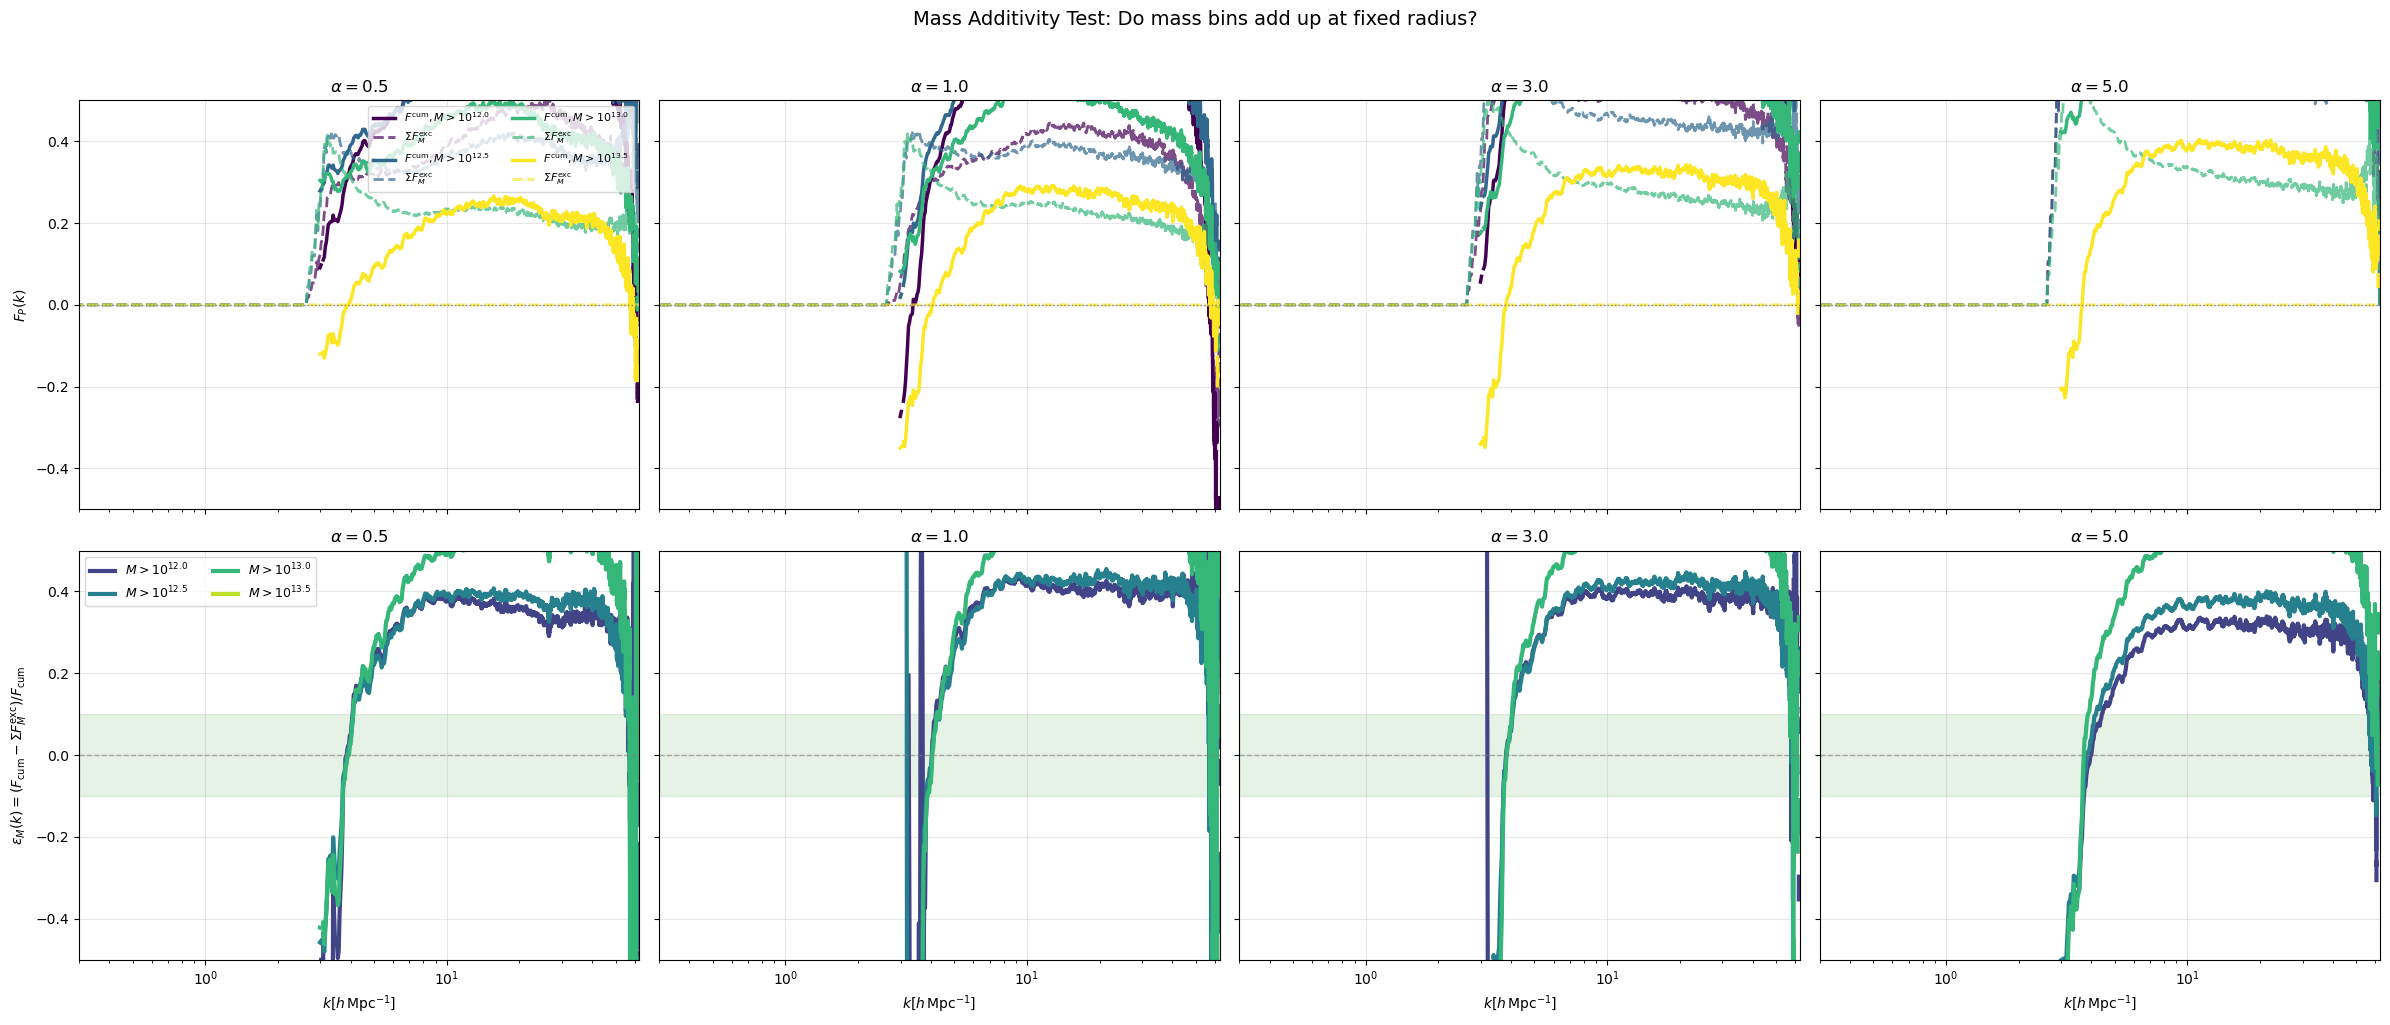


Mass Additivity Summary: ⟨ε_M⟩ across k

α = 0.5:
  M > 10^12.0: ⟨ε_M⟩ = +0.315
  M > 10^12.5: ⟨ε_M⟩ = +0.295
  M > 10^13.0: ⟨ε_M⟩ = +0.409
  M > 10^13.5: ⟨ε_M⟩ = +1.000

α = 1.0:
  M > 10^12.0: ⟨ε_M⟩ = +0.385
  M > 10^12.5: ⟨ε_M⟩ = +0.338
  M > 10^13.0: ⟨ε_M⟩ = +0.445
  M > 10^13.5: ⟨ε_M⟩ = +1.000

α = 3.0:
  M > 10^12.0: ⟨ε_M⟩ = +0.392
  M > 10^12.5: ⟨ε_M⟩ = +0.347
  M > 10^13.0: ⟨ε_M⟩ = +0.454
  M > 10^13.5: ⟨ε_M⟩ = +1.000

α = 5.0:
  M > 10^12.0: ⟨ε_M⟩ = +0.255
  M > 10^12.5: ⟨ε_M⟩ = +0.303
  M > 10^13.0: ⟨ε_M⟩ = +0.467
  M > 10^13.5: ⟨ε_M⟩ = +1.000


In [ ]:
# Figure 6: Mass Additivity Test (Bispectrum)
# Compare F_B^cum(M > M_min, R < α) vs Σ F_B^exc([M_i, M_{i+1}), R < α)
# This tests whether MASS BINS are additive at fixed radius

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)

# For each radius threshold α
for r_idx, alpha in enumerate(RADII):
    ax = axes[0, r_idx]
    
    # For each mass threshold M_min
    for m_idx, ml in enumerate(MASS_THRESHOLDS):
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        
        # Get cumulative F_B(k)
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_bk < NYQUIST_BK)
        
        F_cum_k = np.full_like(Bk_cum, np.nan)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        # Sum exclusive mass bins at fixed radius
        # Mass bins: DISCRETE_MASS_BINS = [(ml, mu), ...]
        # For M > M_min, sum bins where bin_ml >= M_min
        mass_start = MASS_TO_BIN_START[ml]
        F_sum_k = np.zeros_like(k_bk)
        
        for i in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_exc, mu_exc = DISCRETE_MASS_BINS[i]
            exc_key = (ml_exc, mu_exc, alpha)
            if exc_key in exc_mass_cum_radius_bk_all:
                Bk_exc = exc_mass_cum_radius_bk_all[exc_key]['Bk_mean']
                F_exc_k = np.zeros_like(Bk_exc)
                F_exc_k[significant] = (Bk_exc[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                F_sum_k += F_exc_k
        
        F_cum_k_smooth = smooth_logk(F_cum_k, window=9)
        F_sum_k_smooth = smooth_logk(F_sum_k, window=9)
        
        color = plt.cm.viridis(m_idx / (len(MASS_THRESHOLDS) - 1))
        mass_log = np.log10(float(ml))
        
        ax.semilogx(k_bk, F_cum_k_smooth, '-', lw=2.5, color=color, 
                   label=rf'$F_B^{{\rm cum}}, M>10^{{{mass_log:.1f}}}$')
        ax.semilogx(k_bk, F_sum_k_smooth, '--', lw=2, color=color, alpha=0.7,
                   label=rf'$\Sigma F_B^{{\rm exc}}_M$')
    
    ax.axhline(0, color='gray', ls=':', lw=1)
    ax.axhline(1, color='gray', ls=':', lw=1)
    ax.set_xlim(0.3, NYQUIST_BK)
    ax.set_ylim(-0.2, 1.4)
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.grid(True, alpha=0.3)
    if r_idx == 0:
        ax.set_ylabel(r'$F_B(k)$')
        ax.legend(loc='upper right', fontsize=8, ncol=2)

# Bottom row: Mass additivity non-additivity ε_M(k)
colors_mass = plt.cm.viridis(np.linspace(0.2, 0.9, len(MASS_THRESHOLDS)))

for r_idx, alpha in enumerate(RADII):
    ax = axes[1, r_idx]
    
    for m_idx, ml in enumerate(MASS_THRESHOLDS):
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        
        # Get cumulative F_B(k)
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_bk < NYQUIST_BK)
        
        F_cum_k = np.full_like(Bk_cum, np.nan)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        # Sum exclusive mass bins
        mass_start = MASS_TO_BIN_START[ml]
        F_sum_k = np.zeros_like(k_bk)
        
        for i in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_exc, mu_exc = DISCRETE_MASS_BINS[i]
            exc_key = (ml_exc, mu_exc, alpha)
            if exc_key in exc_mass_cum_radius_bk_all:
                Bk_exc = exc_mass_cum_radius_bk_all[exc_key]['Bk_mean']
                F_exc_k = np.zeros_like(Bk_exc)
                F_exc_k[significant] = (Bk_exc[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                F_sum_k += F_exc_k
        
        # Compute ε_M(k) = (F_cum - F_sum) / F_cum
        epsilon_M_k = np.full_like(F_cum_k, np.nan)
        valid = significant & (np.abs(F_cum_k) > 0.01)
        epsilon_M_k[valid] = (F_cum_k[valid] - F_sum_k[valid]) / F_cum_k[valid]
        epsilon_M_k_smooth = smooth_logk(epsilon_M_k, window=9)
        
        mass_log = np.log10(float(ml))
        ax.semilogx(k_bk, epsilon_M_k_smooth, lw=3, color=colors_mass[m_idx],
                   label=rf'$M>10^{{{mass_log:.1f}}}$')
    
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
    ax.axhspan(-0.1, 0.1, alpha=0.1, color='green')
    ax.set_xlim(0.3, NYQUIST_BK)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r'$k [h\,{\rm Mpc}^{-1}]$')
    if r_idx == 0:
        ax.set_ylabel(r'$\varepsilon_M(k) = (F_B^{\rm cum} - \Sigma F_B^{\rm exc}_M) / F_B^{\rm cum}$')
        ax.legend(loc='upper left', fontsize=9, ncol=2)

plt.suptitle('Bispectrum Mass Additivity Test: Do mass bins add up at fixed radius?', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/bispectrum_mass_additivity_test.pdf')
plt.show()

# Summary statistics
print("\nBispectrum Mass Additivity Summary: ⟨ε_M⟩ across k")
print("=" * 60)
for alpha in RADII:
    print(f"\nα = {alpha}:")
    for ml in MASS_THRESHOLDS:
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_bk < NYQUIST_BK)
        
        F_cum_k = np.zeros_like(Bk_cum)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        mass_start = MASS_TO_BIN_START[ml]
        F_sum_k = np.zeros_like(k_bk)
        for i in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_exc, mu_exc = DISCRETE_MASS_BINS[i]
            exc_key = (ml_exc, mu_exc, alpha)
            if exc_key in exc_mass_cum_radius_bk_all:
                Bk_exc = exc_mass_cum_radius_bk_all[exc_key]['Bk_mean']
                F_exc_k = np.zeros_like(Bk_exc)
                F_exc_k[significant] = (Bk_exc[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                F_sum_k += F_exc_k
        
        valid = significant & (np.abs(F_cum_k) > 0.01)
        epsilon_M = (F_cum_k[valid] - F_sum_k[valid]) / F_cum_k[valid]
        mass_log = np.log10(float(ml))
        print(f"  M > 10^{mass_log:.1f}: ⟨ε_M⟩ = {np.nanmean(epsilon_M):+.3f}")

### Figure 7: Comparison of Non-Additivity Sources (Bispectrum)

Compare the full non-additivity ε (from Figure 5) with mass-only non-additivity ε_M (from Figure 6):

- **ε** = (F_B^cum - Σ tiles) / F_B^cum — full non-additivity from discrete tiles
- **ε_M** = (F_B^cum - Σ mass bins) / F_B^cum — mass-only non-additivity at fixed radius

If ε ≈ ε_M: Non-additivity is dominated by **mass cross-terms** (different halos)
If ε >> ε_M: Non-additivity is dominated by **radial cross-terms** (same halo, different shells)

**Bispectrum note**: Three-point correlations may show enhanced sensitivity to cross-terms compared to two-point statistics.

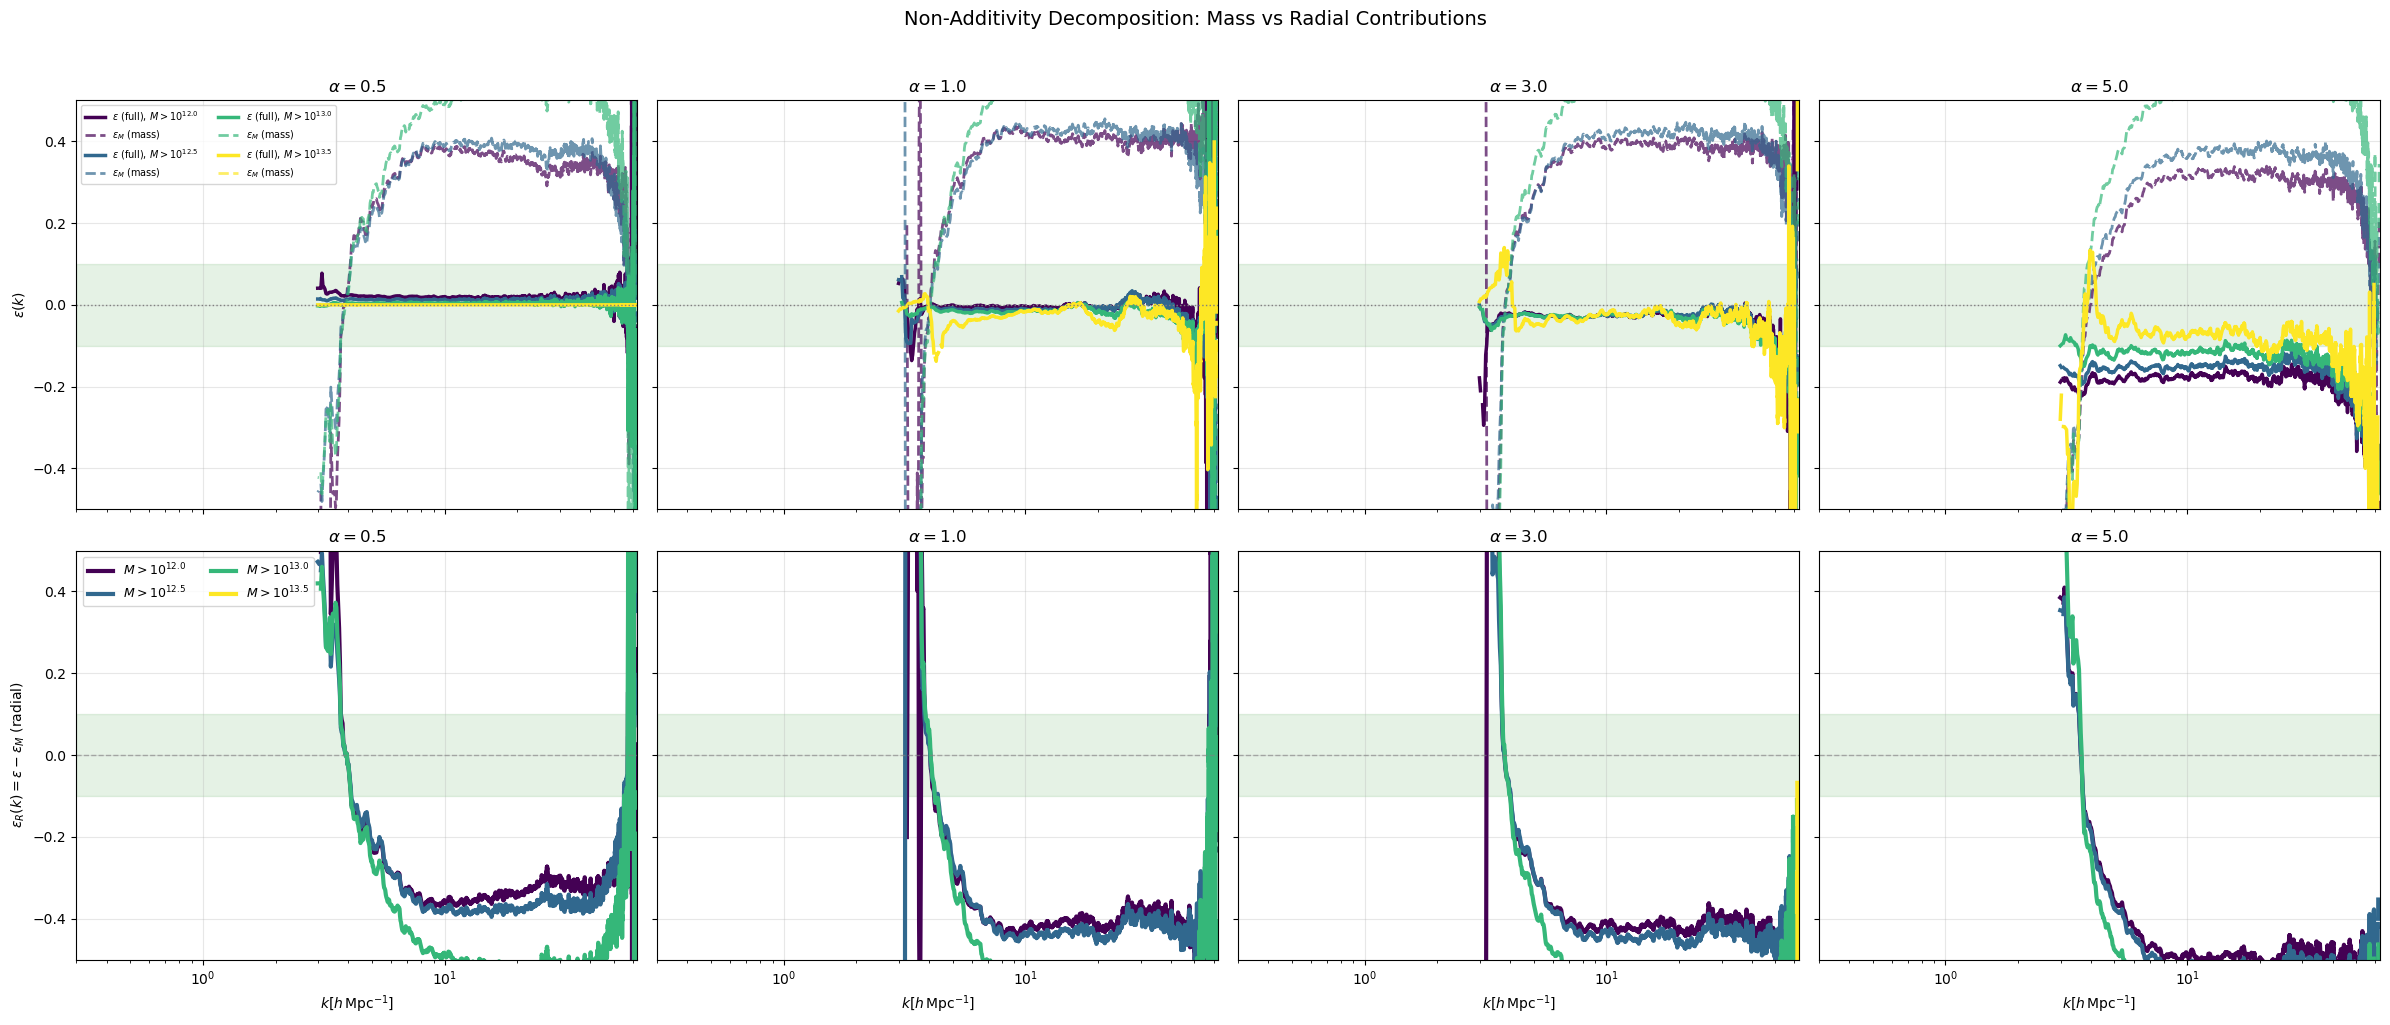


Non-Additivity Decomposition Summary:
α      M_min        ⟨ε⟩          ⟨ε_M⟩        ⟨ε_R⟩        % from radius
----------------------------------------------------------------------
0.5    10^12.0      +0.023       +0.315       -0.292       48.1%
0.5    10^12.5      +0.012       +0.295       -0.283       48.9%
0.5    10^13.0      -0.002       +0.409       -0.411       50.1%
0.5    10^13.5      +0.000       +1.000       -1.000       50.0%
1.0    10^12.0      +0.012       +0.385       -0.373       49.2%
1.0    10^12.5      -0.063       +0.338       -0.402       54.3%
1.0    10^13.0      -0.030       +0.445       -0.476       51.6%
1.0    10^13.5      -0.035       +1.000       -1.035       50.9%
3.0    10^12.0      -0.098       +0.392       -0.491       55.6%
3.0    10^12.5      -0.065       +0.347       -0.412       54.3%
3.0    10^13.0      -0.076       +0.454       -0.530       53.8%
3.0    10^13.5      -0.067       +1.000       -1.067       51.6%
5.0    10^12.0      -0.235       +0.2

In [ ]:
# Figure 7: Compare full ε vs mass-only ε_M (Bispectrum)
# This reveals whether non-additivity comes from mass or radius cross-terms

fig, axes = plt.subplots(2, 4, figsize=(24, 10), sharex=True, sharey=True)

# For each radius threshold α
for r_idx, alpha in enumerate(RADII):
    ax = axes[0, r_idx]
    radius_end = RADIUS_TO_BIN_END[alpha]
    
    for m_idx, ml in enumerate(MASS_THRESHOLDS):
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        
        # F_B^cum(k) from cumulative model
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_bk < NYQUIST_BK)
        
        F_cum_k = np.full_like(Bk_cum, np.nan)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        mass_start = MASS_TO_BIN_START[ml]
        
        # Compute F_sum from discrete tiles (mass × radius tiles)
        F_sum_tiles_k = np.zeros_like(k_bk)
        for ii in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_tile, mu_tile = DISCRETE_MASS_BINS[ii]
            for jj in range(radius_end):
                ri_tile, ro_tile = DISCRETE_RADIUS_BINS[jj]
                tile_key = (ml_tile, mu_tile, ri_tile, ro_tile)
                if tile_key in discrete_bk_all:
                    Bk_tile = discrete_bk_all[tile_key]['Bk_mean']
                    Delta_F_tile = np.zeros_like(Bk_tile)
                    Delta_F_tile[significant] = (Bk_tile[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                    F_sum_tiles_k += Delta_F_tile
        
        # Compute F_sum from exclusive mass bins at fixed radius
        F_sum_mass_k = np.zeros_like(k_bk)
        for i in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_exc, mu_exc = DISCRETE_MASS_BINS[i]
            exc_key = (ml_exc, mu_exc, alpha)
            if exc_key in exc_mass_cum_radius_bk_all:
                Bk_exc = exc_mass_cum_radius_bk_all[exc_key]['Bk_mean']
                F_exc_k = np.zeros_like(Bk_exc)
                F_exc_k[significant] = (Bk_exc[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                F_sum_mass_k += F_exc_k
        
        # ε_full = (F_cum - F_tiles) / F_cum
        epsilon_full_k = np.full_like(F_cum_k, np.nan)
        valid = significant & (np.abs(F_cum_k) > 0.01)
        epsilon_full_k[valid] = (F_cum_k[valid] - F_sum_tiles_k[valid]) / F_cum_k[valid]
        
        # ε_M = (F_cum - F_mass_bins) / F_cum
        epsilon_M_k = np.full_like(F_cum_k, np.nan)
        epsilon_M_k[valid] = (F_cum_k[valid] - F_sum_mass_k[valid]) / F_cum_k[valid]
        
        epsilon_full_smooth = smooth_logk(epsilon_full_k, window=9)
        epsilon_M_smooth = smooth_logk(epsilon_M_k, window=9)
        
        color = plt.cm.viridis(m_idx / (len(MASS_THRESHOLDS) - 1))
        mass_log = np.log10(float(ml))
        
        ax.semilogx(k_bk, epsilon_full_smooth, '-', lw=2.5, color=color,
                   label=rf'$\varepsilon$ (full), $M>10^{{{mass_log:.1f}}}$')
        ax.semilogx(k_bk, epsilon_M_smooth, '--', lw=2, color=color, alpha=0.7,
                   label=rf'$\varepsilon_M$ (mass)')
    
    ax.axhline(0, color='gray', ls=':', lw=1)
    ax.axhspan(-0.1, 0.1, alpha=0.1, color='green')
    ax.set_xlim(0.3, NYQUIST_BK)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.grid(True, alpha=0.3)
    if r_idx == 0:
        ax.set_ylabel(r'$\varepsilon(k)$')
        ax.legend(loc='upper left', fontsize=7, ncol=2)

# Bottom row: Difference ε - ε_M (radial contribution to non-additivity)
for r_idx, alpha in enumerate(RADII):
    ax = axes[1, r_idx]
    radius_end = RADIUS_TO_BIN_END[alpha]
    
    for m_idx, ml in enumerate(MASS_THRESHOLDS):
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_bk < NYQUIST_BK)
        
        F_cum_k = np.full_like(Bk_cum, np.nan)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        mass_start = MASS_TO_BIN_START[ml]
        
        # F_sum from tiles
        F_sum_tiles_k = np.zeros_like(k_bk)
        for ii in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_tile, mu_tile = DISCRETE_MASS_BINS[ii]
            for jj in range(radius_end):
                ri_tile, ro_tile = DISCRETE_RADIUS_BINS[jj]
                tile_key = (ml_tile, mu_tile, ri_tile, ro_tile)
                if tile_key in discrete_bk_all:
                    Bk_tile = discrete_bk_all[tile_key]['Bk_mean']
                    Delta_F_tile = np.zeros_like(Bk_tile)
                    Delta_F_tile[significant] = (Bk_tile[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                    F_sum_tiles_k += Delta_F_tile
        
        # F_sum from mass bins
        F_sum_mass_k = np.zeros_like(k_bk)
        for i in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_exc, mu_exc = DISCRETE_MASS_BINS[i]
            exc_key = (ml_exc, mu_exc, alpha)
            if exc_key in exc_mass_cum_radius_bk_all:
                Bk_exc = exc_mass_cum_radius_bk_all[exc_key]['Bk_mean']
                F_exc_k = np.zeros_like(Bk_exc)
                F_exc_k[significant] = (Bk_exc[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                F_sum_mass_k += F_exc_k
        
        valid = significant & (np.abs(F_cum_k) > 0.01)
        
        # ε_R = ε - ε_M = contribution from radial cross-terms
        epsilon_full_k = np.full_like(F_cum_k, np.nan)
        epsilon_full_k[valid] = (F_cum_k[valid] - F_sum_tiles_k[valid]) / F_cum_k[valid]
        epsilon_M_k = np.full_like(F_cum_k, np.nan)
        epsilon_M_k[valid] = (F_cum_k[valid] - F_sum_mass_k[valid]) / F_cum_k[valid]
        
        epsilon_R_k = epsilon_full_k - epsilon_M_k  # Radial contribution
        epsilon_R_smooth = smooth_logk(epsilon_R_k, window=9)
        
        color = plt.cm.viridis(m_idx / (len(MASS_THRESHOLDS) - 1))
        mass_log = np.log10(float(ml))
        
        ax.semilogx(k_bk, epsilon_R_smooth, lw=3, color=color,
                   label=rf'$M>10^{{{mass_log:.1f}}}$')
    
    ax.axhline(0, color='gray', ls='--', lw=1, alpha=0.6)
    ax.axhspan(-0.1, 0.1, alpha=0.1, color='green')
    ax.set_xlim(0.3, NYQUIST_BK)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(rf'$\alpha = {alpha}$')
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r'$k [h\,{\rm Mpc}^{-1}]$')
    if r_idx == 0:
        ax.set_ylabel(r'$\varepsilon_R(k) = \varepsilon - \varepsilon_M$ (radial)')
        ax.legend(loc='upper left', fontsize=9, ncol=2)

plt.suptitle('Bispectrum Non-Additivity Decomposition: Mass vs Radial Contributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('/mnt/home/mlee1/hydro_replace2/notebooks/figures/bispectrum_non_additivity_decomposition.pdf')
plt.show()

# Summary
print("\nBispectrum Non-Additivity Decomposition Summary:")
print("=" * 70)
print(f"{'α':<6} {'M_min':<12} {'⟨ε⟩':<12} {'⟨ε_M⟩':<12} {'⟨ε_R⟩':<12} {'% from radius'}")
print("-" * 70)
for alpha in RADII:
    radius_end = RADIUS_TO_BIN_END[alpha]
    for ml in MASS_THRESHOLDS:
        cum_key = (ml, alpha)
        if cum_key not in cumulative_bk_all:
            continue
        
        Bk_cum = cumulative_bk_all[cum_key]['Bk_mean']
        Delta_B = bk_hydro_mean - bk_dmo_mean
        significant = (np.abs(Delta_B) > BARYONIC_THRESHOLD * np.abs(bk_dmo_mean)) & (k_bk < NYQUIST_BK)
        
        F_cum_k = np.zeros_like(Bk_cum)
        F_cum_k[significant] = (Bk_cum[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
        
        mass_start = MASS_TO_BIN_START[ml]
        
        F_sum_tiles_k = np.zeros_like(k_bk)
        for ii in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_tile, mu_tile = DISCRETE_MASS_BINS[ii]
            for jj in range(radius_end):
                ri_tile, ro_tile = DISCRETE_RADIUS_BINS[jj]
                tile_key = (ml_tile, mu_tile, ri_tile, ro_tile)
                if tile_key in discrete_bk_all:
                    Bk_tile = discrete_bk_all[tile_key]['Bk_mean']
                    Delta_F_tile = np.zeros_like(Bk_tile)
                    Delta_F_tile[significant] = (Bk_tile[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                    F_sum_tiles_k += Delta_F_tile
        
        F_sum_mass_k = np.zeros_like(k_bk)
        for i in range(mass_start, len(DISCRETE_MASS_BINS)):
            ml_exc, mu_exc = DISCRETE_MASS_BINS[i]
            exc_key = (ml_exc, mu_exc, alpha)
            if exc_key in exc_mass_cum_radius_bk_all:
                Bk_exc = exc_mass_cum_radius_bk_all[exc_key]['Bk_mean']
                F_exc_k = np.zeros_like(Bk_exc)
                F_exc_k[significant] = (Bk_exc[significant] - bk_dmo_mean[significant]) / Delta_B[significant]
                F_sum_mass_k += F_exc_k
        
        valid = significant & (np.abs(F_cum_k) > 0.01)
        eps_full = np.nanmean((F_cum_k[valid] - F_sum_tiles_k[valid]) / F_cum_k[valid])
        eps_M = np.nanmean((F_cum_k[valid] - F_sum_mass_k[valid]) / F_cum_k[valid])
        eps_R = eps_full - eps_M
        pct_radius = abs(eps_R) / (abs(eps_M) + abs(eps_R) + 1e-10) * 100
        
        mass_log = np.log10(float(ml))
        print(f"{alpha:<6} {f'10^{mass_log:.1f}':<12} {eps_full:+.3f}       {eps_M:+.3f}       {eps_R:+.3f}       {pct_radius:.1f}%")